# Figure 1

Computational panels C and E–F.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
from pathlib import Path

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)

# Override this environment variable when the shared data directory is mounted elsewhere.
DATA_ROOT = Path(
    os.environ.get("BIOAGENTS_DATA_ROOT", "/gpfs/group/jin/asun/bioagents/data")
)
DEG_PATH = DATA_ROOT / "wilcoxon_de_results_group_name_final_data_no_multi_guide_cells.parquet"
REPORTS_PATH = DATA_ROOT / "perturbai_reports" / "reports" / "html"


## Figure 1C — source-study findings

Each dot represents one gene × source-study finding pair.

Figure 1C: 71 source-study finding pairs across 62 unique genes; 35 match, 13 refines, 9 partial, 14 diverges
Directly testable: 55; matched/refined = 48, partial = 4, not covered = 3.


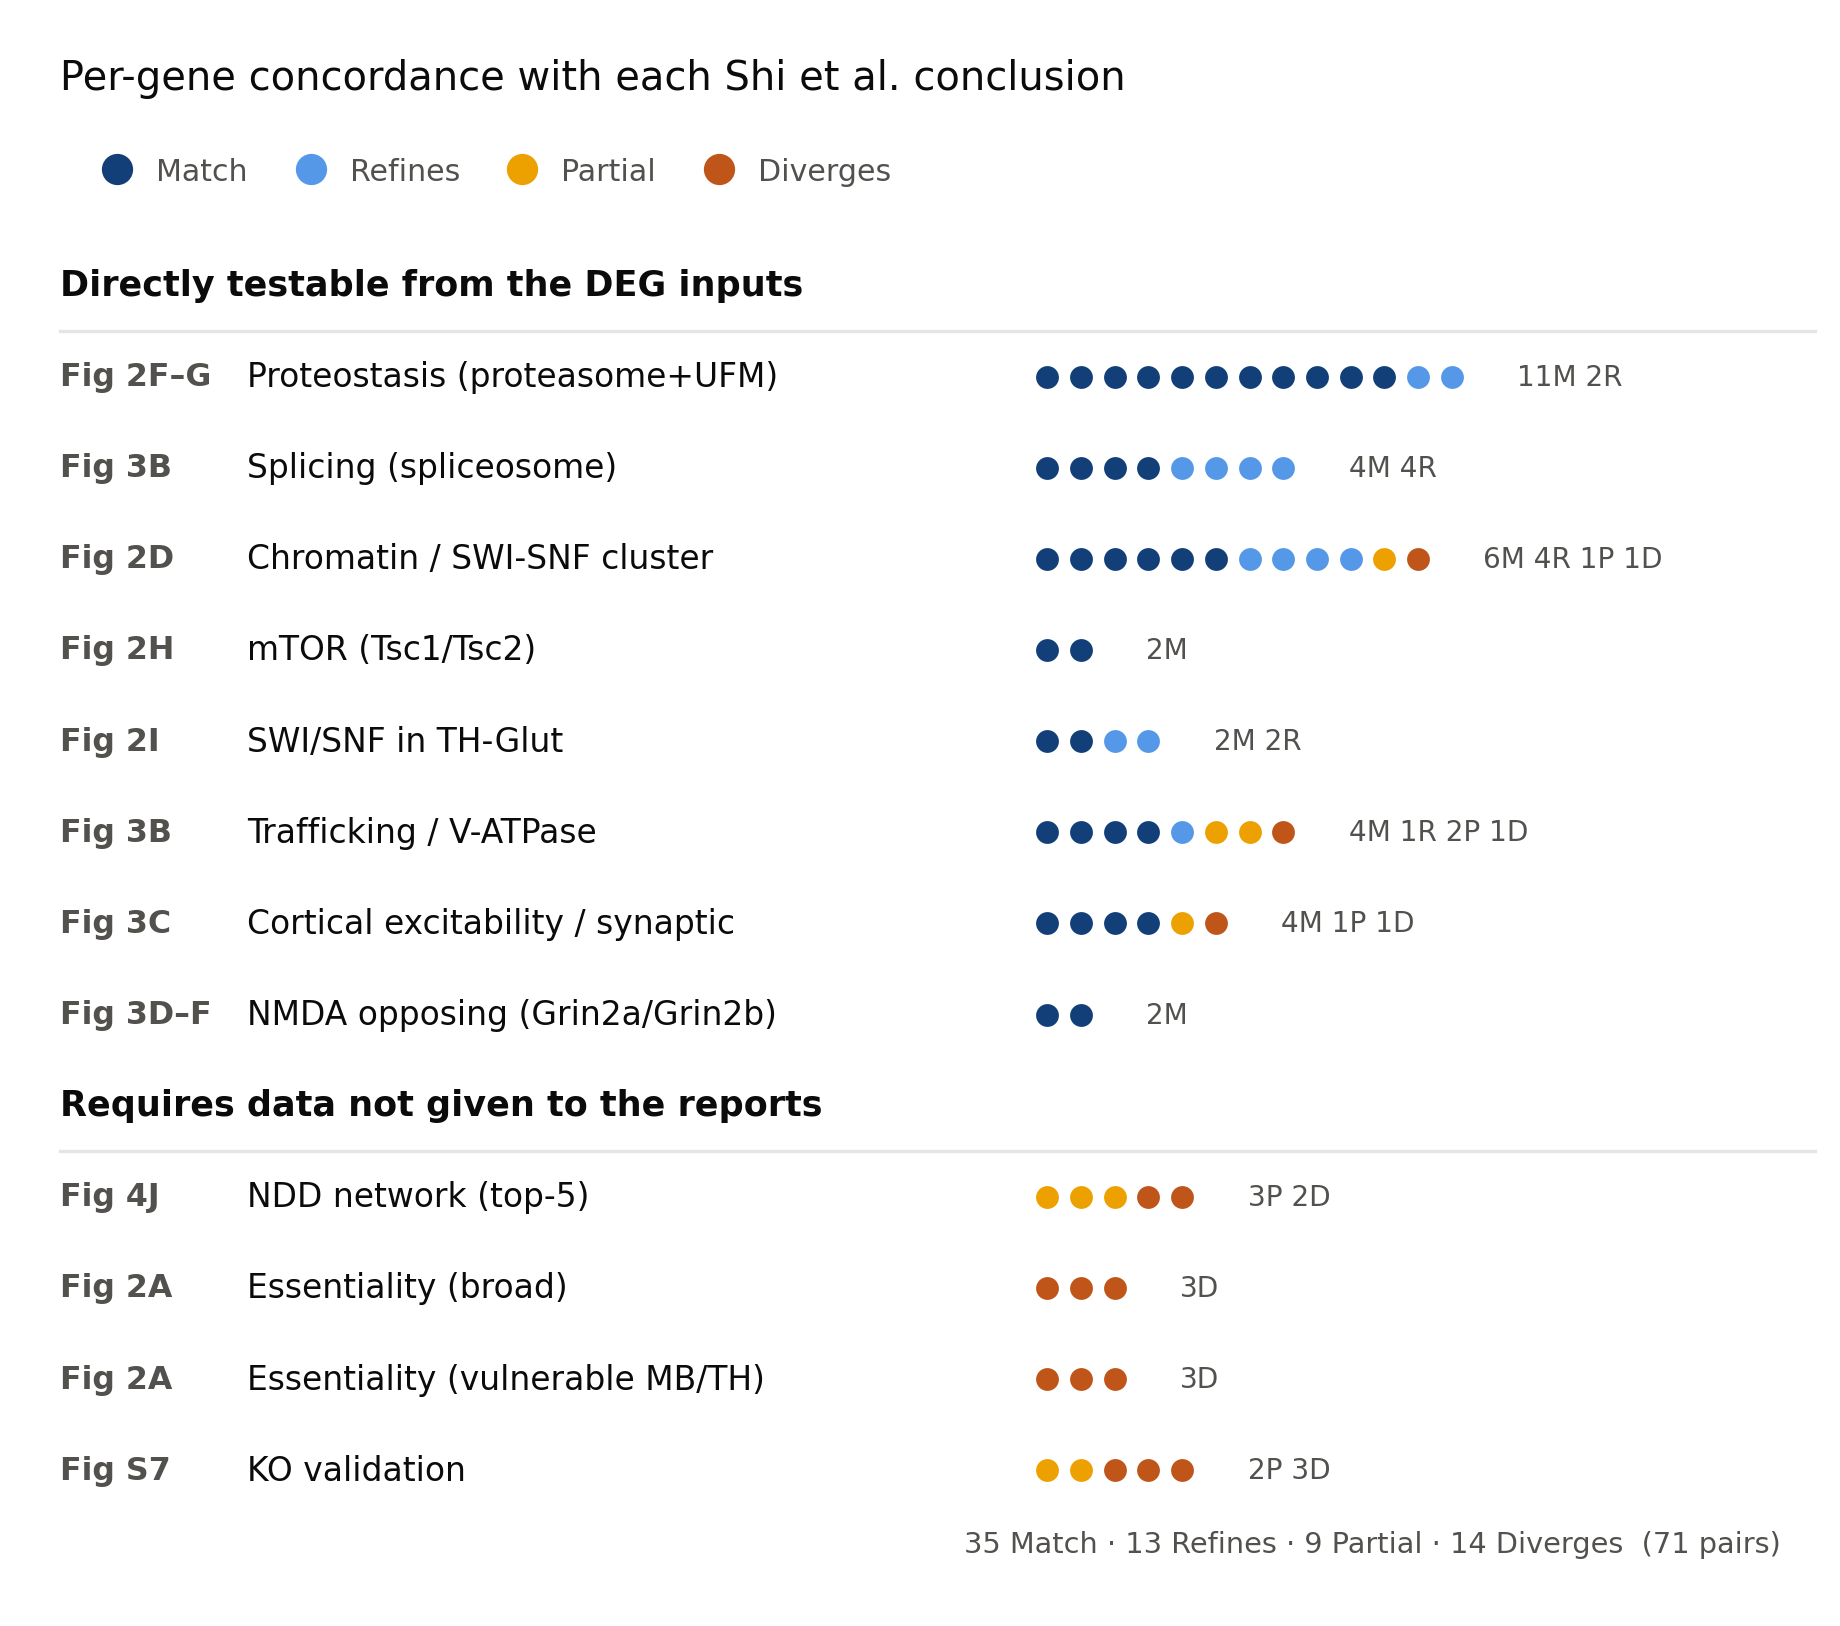

In [2]:
from collections import Counter

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})
import pandas as pd

FIG1C_DIR = ROOT / "src/manuscript_figures/fig1/c"
verdicts = pd.read_csv(FIG1C_DIR / "alignment_verdicts.csv")

VERDICTS = [("M", "Match"), ("R", "Refines"), ("P", "Partial"), ("D", "Diverges")]
VERDICT_RANK = {code: rank for rank, (code, _) in enumerate(VERDICTS)}
HEADLINE_ORDER = ("2a", "2b", "2c", "2d", "3c", "4b", "4e", "5", "7", "1a", "1b", "8")
SCOPE_ORDER = ("direct", "external")
SCOPE_LABELS = {
    "direct": "Directly testable from the DEG inputs",
    "external": "Requires data not given to the reports",
}
EXPECTED_TOTALS = {"M": 35, "R": 13, "P": 9, "D": 14}

assert verdicts.columns.tolist() == [
    "headline_id", "paper_figure", "headline", "input_scope", "gene", "verdict"
]
assert len(verdicts) == 71
assert verdicts[["headline_id", "gene"]].drop_duplicates().shape[0] == 71
assert verdicts.gene.nunique() == 62
assert tuple(verdicts.headline_id.drop_duplicates()) == HEADLINE_ORDER
assert Counter(verdicts.verdict) == Counter(EXPECTED_TOTALS)
assert set(verdicts.input_scope) == set(SCOPE_ORDER)
for headline_id, group in verdicts.groupby("headline_id", sort=False):
    assert group[["paper_figure", "headline", "input_scope"]].drop_duplicates().shape[0] == 1

direct = verdicts[verdicts.input_scope.eq("direct")]
direct_counts = Counter(direct.verdict)
print(
    f"Figure 1C: {len(verdicts)} source-study finding pairs across "
    f"{verdicts.gene.nunique()} unique genes; "
    + ", ".join(f"{EXPECTED_TOTALS[c]} {name.lower()}" for c, name in VERDICTS)
)
print(
    f"Directly testable: {len(direct)}; matched/refined = "
    f"{direct_counts['M'] + direct_counts['R']}, partial = {direct_counts['P']}, "
    f"not covered = {direct_counts['D']}."
)

colors = {"M": "#123f78", "R": "#5598e7", "P": "#eda100", "D": "#c0551a"}
W, H = 427.32, 376.074
LEFT, FIG_X, LABEL_X = 7.2, 7.2, 52.0
DOT_X0, DOT_GAP, DOT_S, COUNT_PAD = 244.165205, 8.089876, 30.0, 7.59
ROW0_Y, ROW_STEP, GROUP_GAP_ROWS = 83.414571, 21.874286, 1
HEADER_DY, RULE_DY = -19.589223, -10.937142
INK, MUTED, RULE_COLOR = "#0b0b0b", "#52514e", "#e6e5e2"

fig = plt.figure(figsize=(W / 72, H / 72))
ax = fig.add_axes((0, 0, 1, 1))
ax.set_xlim(0, W)
ax.set_ylim(H, 0)
ax.axis("off")
fig.patch.set_visible(False)
ax.patch.set_visible(False)

fig.text(
    LEFT / W, 1 - 14.4945 / H,
    "Per-gene concordance with each Shi et al. conclusion",
    fontsize=9.6, color=INK, va="baseline",
)
for x, (code, name) in zip([20.88, 67.329, 118.197, 165.301875], VERDICTS):
    ax.scatter([x], [33.609105], s=56.25, color=colors[code], linewidths=0, clip_on=False)
    ax.text(x + 9.36, 36.129105, name, fontsize=7.2, color=MUTED, va="baseline", clip_on=False)

tally = Counter()
slot = 0
for scope in SCOPE_ORDER:
    scope_rows = verdicts[verdicts.input_scope.eq(scope)]
    ordered_headlines = [h for h in HEADLINE_ORDER if h in set(scope_rows.headline_id)]
    first_y = ROW0_Y + ROW_STEP * slot
    ax.plot([LEFT, W + 1], [first_y + RULE_DY] * 2, color=RULE_COLOR, lw=.8, clip_on=False)
    ax.text(
        LEFT, first_y + HEADER_DY, SCOPE_LABELS[scope],
        fontsize=8.4, fontweight="bold", color=INK, va="baseline", clip_on=False,
    )
    for headline_id in ordered_headlines:
        rows = scope_rows[scope_rows.headline_id.eq(headline_id)].copy()
        rows["rank"] = rows.verdict.map(VERDICT_RANK)
        rows = rows.sort_values("rank")
        first = rows.iloc[0]
        codes = rows.verdict.tolist()
        y = ROW0_Y + ROW_STEP * slot
        ax.text(FIG_X, y, first.paper_figure, fontsize=7.6, fontweight="bold", color=MUTED, va="center")
        ax.text(LABEL_X, y, first.headline, fontsize=7.9, color=INK, va="center")
        for code, _ in VERDICTS:
            xs = [DOT_X0 + DOT_GAP * i for i, observed in enumerate(codes) if observed == code]
            if xs:
                ax.scatter(xs, [y] * len(xs), s=DOT_S, color=colors[code], linewidths=0, clip_on=False)
        counts = Counter(codes)
        ax.text(
            DOT_X0 + DOT_GAP * len(codes) + COUNT_PAD, y,
            " ".join(f"{counts[code]}{code}" for code, _ in VERDICTS if counts[code]),
            fontsize=6.7, color=MUTED, va="center", clip_on=False,
        )
        tally.update(codes)
        slot += 1
    slot += GROUP_GAP_ROWS

footer = " · ".join(f"{tally[code]} {name}" for code, name in VERDICTS) + f"  ({len(verdicts)} pairs)"
ax.text(420.12, 365.592857, footer, fontsize=6.9, color=MUTED, ha="right", va="baseline", clip_on=False)
fig.savefig(FIG1C_DIR / "C_source_study_finding_recovery.pdf", bbox_inches=None, pad_inches=0)
plt.show()

## Figure 1E — proteostasis report similarity

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
plt.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none'})
REPORT_DIR = REPORTS_PATH
OUT_DIR = ROOT / 'src/manuscript_figures/fig1/e'
TARGETS = ['Psmb4', 'Pomp', 'Hspa5', 'Hspa8', 'Hspa9', 'Lonp1', 'Opa1', 'Dnm1l']

### Values and arithmetic means

In [4]:
NUMERIC_CELLS = [('Psmb4', 'Pomp', [0.984], '180-gene recurrent panel'), ('Pomp', 'Psmb4', [0.963, 0.942, 0.941], '155 MB, 066 HY GABA, 052 Pvalb'), ('Hspa8', 'Hspa9', [0.334], '151 TH Prkcd Grin2c Glut'), ('Hspa8', 'Psmb4', [0.289], '151 TH Prkcd Grin2c Glut'), ('Hspa9', 'Hspa5', [0.82], '151 TH Prkcd Grin2c Glut'), ('Hspa9', 'Dnm1l', [0.78, 0.87], '151 TH and 155 MB'), ('Hspa9', 'Opa1', [0.77, 0.83], '151 TH and 155 MB'), ('Hspa9', 'Hspa8', [0.69, 0.83], '151 TH and 155 MB'), ('Hspa9', 'Psmb4', [0.68, 0.81], '151 TH and 155 MB'), ('Lonp1', 'Opa1', [0.176, 0.2, 0.186], '155 MB, 191 MB P MY, Pineal'), ('Lonp1', 'Hspa9', [0.213, 0.189], '155 MB and 191 MB P MY'), ('Lonp1', 'Dnm1l', [0.153, 0.198], '155 MB and 191 MB P MY'), ('Opa1', 'Hspa9', [0.93], 'reported mean across five responsive groups'), ('Opa1', 'Lonp1', [0.89], 'reported mean across five responsive groups'), ('Opa1', 'Dnm1l', [0.87], 'reported mean across five responsive groups'), ('Dnm1l', 'Hspa9', [0.963, 0.932, 0.909], '151 TH, 191 MB P MY, 155 MB'), ('Dnm1l', 'Opa1', [0.935, 0.874, 0.921], '151 TH, 191 MB P MY, 155 MB'), ('Dnm1l', 'Hspa5', [0.909], '151 TH Prkcd Grin2c Glut'), ('Dnm1l', 'Lonp1', [0.868, 0.85, 0.887], '151 TH, 191 MB P MY, 155 MB'), ('Dnm1l', 'Hspa8', [0.886, 0.859], '191 MB P MY and 155 MB')]
numeric = pd.DataFrame(NUMERIC_CELLS, columns=['report', 'compared_target', 'reported_values', 'reported_context'])
numeric['mean_similarity'] = numeric['reported_values'].map(np.mean)
numeric['display'] = numeric['mean_similarity'].map(lambda value: f'{value:.2g}')
display(numeric)

,report,compared_target,reported_values,reported_context,mean_similarity,display
0,Psmb4,Pomp,[0.984],180-gene recurrent panel,0.984000,0.98
1,Pomp,Psmb4,"[0.963, 0.942, 0.941]","155 MB, 066 HY GABA, 052 Pvalb",0.948667,0.95
2,Hspa8,Hspa9,[0.334],151 TH Prkcd Grin2c Glut,0.334000,0.33
3,Hspa8,Psmb4,[0.289],151 TH Prkcd Grin2c Glut,0.289000,0.29
4,Hspa9,Hspa5,[0.82],151 TH Prkcd Grin2c Glut,0.820000,0.82
5,Hspa9,Dnm1l,"[0.78, 0.87]",151 TH and 155 MB,0.825000,0.82
6,Hspa9,Opa1,"[0.77, 0.83]",151 TH and 155 MB,0.800000,0.8
7,Hspa9,Hspa8,"[0.69, 0.83]",151 TH and 155 MB,0.760000,0.76
8,Hspa9,Psmb4,"[0.68, 0.81]",151 TH and 155 MB,0.745000,0.75
9,Lonp1,Opa1,"[0.176, 0.2, 0.186]","155 MB, 191 MB P MY, Pineal",0.187333,0.19


### Value checks

In [5]:
html_text = {}
for target in TARGETS:
    path = REPORT_DIR / f'{target.lower()}.html'
    assert path.exists(), path
    html_text[target] = ' '.join(BeautifulSoup(path.read_text(errors='replace'), 'html.parser').get_text(' ', strip=True).split())
for row in numeric.itertuples(index=False):
    assert row.compared_target in html_text[row.report]
    for value in row.reported_values:
        variants = {str(value), f'{value:.3f}', f'{value:.2f}'}
        assert any((v in html_text[row.report] for v in variants)), (row.report, row.compared_target, value)


### Directed similarity heatmap

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


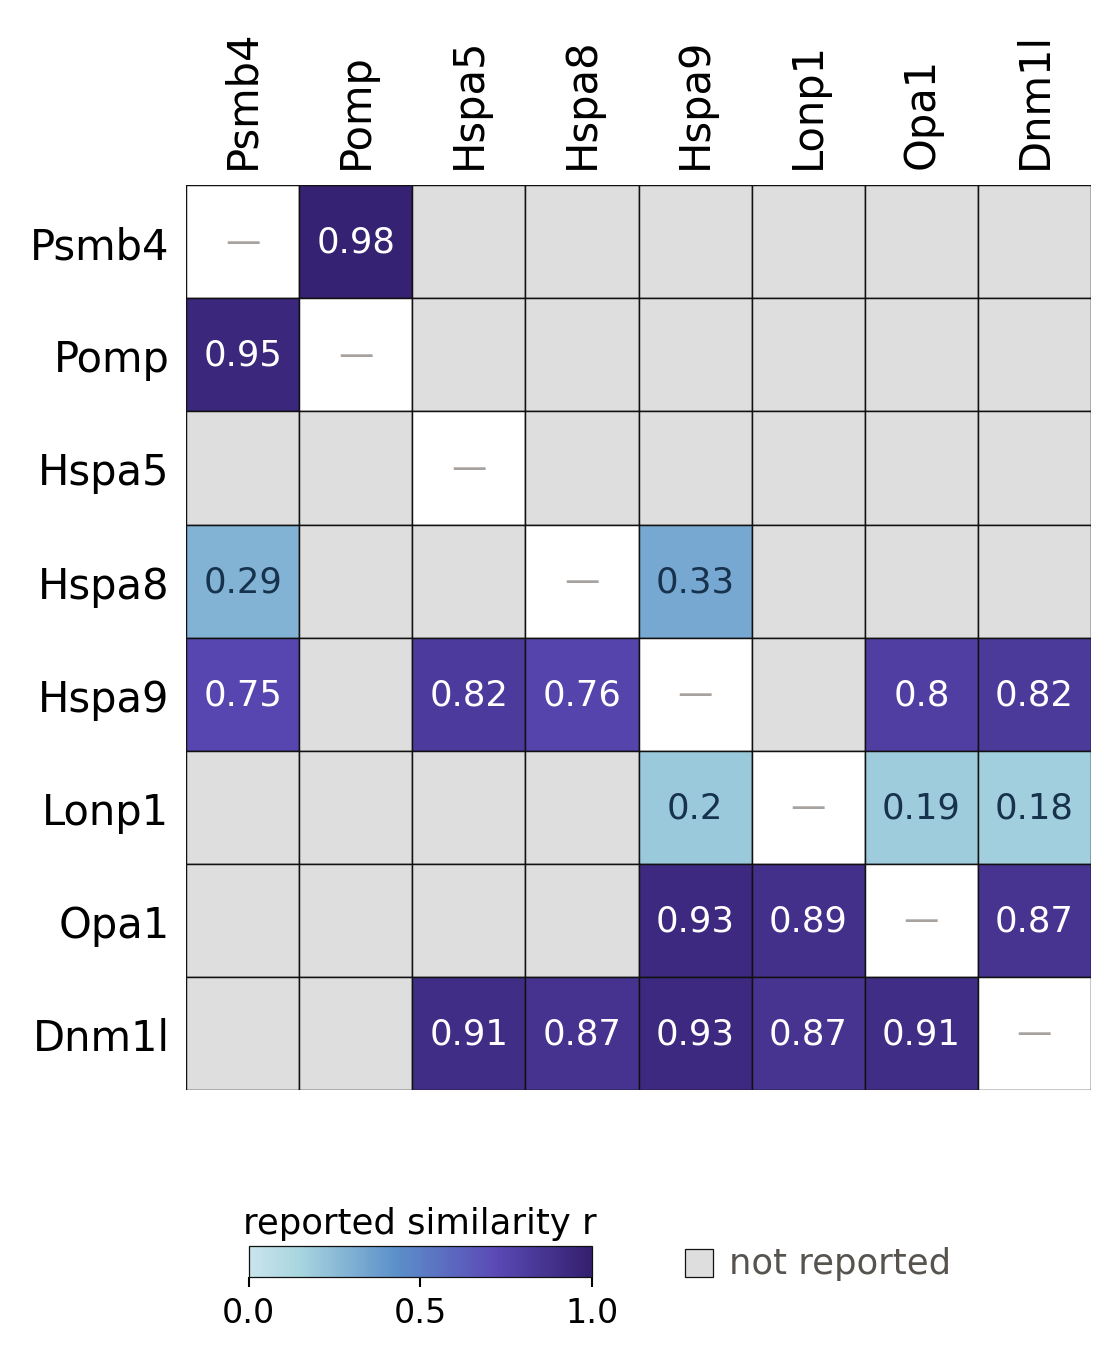

In [6]:
from matplotlib.colors import LinearSegmentedColormap
FIG_W_IN = FIG_H_IN = 5.2
fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN))
index = {target: i for i, target in enumerate(TARGETS)}
cell_lookup = {(r.report, r.compared_target): r for r in numeric.itertuples(index=False)}
cmap = LinearSegmentedColormap.from_list('report_similarity', ['#e8f3f8', '#a8d5df', '#5b8fc9', '#5b4bb7', '#34206f'])
norm = Normalize(vmin=0, vmax=1)
heatmap_cmap = LinearSegmentedColormap.from_list('report_similarity_mapped', [cmap(x) for x in np.linspace(0.12, 1.0, 256)])
for row_target in TARGETS:
    for col_target in TARGETS:
        y, x = (index[row_target], index[col_target])
        item = cell_lookup.get((row_target, col_target))
        is_self = row_target == col_target
        if is_self:
            face = '#ffffff'
            label = '—'
            text_color = '#a8a29e'
        elif item is None:
            face = '#dedede'
            label = ''
            text_color = '#555555'
        else:
            face = heatmap_cmap(norm(item.mean_similarity))
            label = item.display
            text_color = 'white' if item.mean_similarity >= 0.52 else '#17324d'
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor=face, edgecolor='#111111', linewidth=0.35))
        if label:
            ax.text(x, y, label, ha='center', va='center', fontsize=8.5, color=text_color, weight='normal')
ax.set_xlim(-0.5, len(TARGETS) - 0.5)
ax.set_ylim(len(TARGETS) - 0.5, -0.5)
ax.set_aspect('equal')
ax.set_xticks(range(len(TARGETS)), TARGETS, rotation=90, ha='center', va='bottom')
ax.xaxis.tick_top()
ax.set_yticks(range(len(TARGETS)), TARGETS)
ax.tick_params(axis='x', labelsize=10, length=0, pad=4)
ax.tick_params(axis='y', labelsize=10, length=0, pad=4)
for spine in ax.spines.values():
    spine.set_visible(False)
from matplotlib.cm import ScalarMappable
cax = fig.add_axes([0.345, 0.08, 0.22, 0.02])
colorbar = fig.colorbar(ScalarMappable(norm=norm, cmap=heatmap_cmap), cax=cax, orientation='horizontal', ticks=[0, 0.5, 1.0])
colorbar.ax.tick_params(labelsize=8, length=2.5, width=0.5, pad=2)
colorbar.outline.set_edgecolor('#111111')
colorbar.outline.set_linewidth(0.3)
cax.set_title('reported similarity r', fontsize=8.5, pad=3)
missing_key = Rectangle((0.625, 0.08), 0.018, 0.018, transform=fig.transFigure, facecolor='#dedede', edgecolor='#111111', linewidth=0.3, clip_on=False)
fig.add_artist(missing_key)
fig.text(0.653, 0.089, 'not reported', fontsize=8.5, va='center', color='#57534e')
fig.subplots_adjust(left=0.22, right=0.97, bottom=0.20, top=0.78)
plt.show()

## Figure 1E — proteostasis similarity by cell type

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
plt.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'pdf.fonttype': 42, 'ps.fonttype': 42, 'svg.fonttype': 'none'})
REPORT_DIR = REPORTS_PATH
OUT_DIR = ROOT / 'src/manuscript_figures/fig1/e'
CELL_TYPES = ['151 TH', '155 MB', '191 MB/P/MY', '066 HY GABA', '052 Pvalb']

### Cell-type values

In [8]:
REPORTED_VALUES = [('Psmb4', 'Pomp', '155 MB', 0.951), ('Pomp', 'Psmb4', '155 MB', 0.963), ('Pomp', 'Psmb4', '066 HY GABA', 0.942), ('Pomp', 'Psmb4', '052 Pvalb', 0.941), ('Hspa8', 'Hspa9', '151 TH', 0.334), ('Hspa8', 'Psmb4', '151 TH', 0.289), ('Hspa9', 'Dnm1l', '151 TH', 0.78), ('Hspa9', 'Dnm1l', '155 MB', 0.87), ('Hspa9', 'Hspa8', '151 TH', 0.69), ('Hspa9', 'Hspa8', '155 MB', 0.83), ('Hspa9', 'Psmb4', '151 TH', 0.68), ('Hspa9', 'Psmb4', '155 MB', 0.81), ('Lonp1', 'Hspa9', '155 MB', 0.213), ('Lonp1', 'Hspa9', '191 MB/P/MY', 0.189), ('Lonp1', 'Dnm1l', '155 MB', 0.153), ('Lonp1', 'Dnm1l', '191 MB/P/MY', 0.198), ('Dnm1l', 'Hspa9', '151 TH', 0.963), ('Dnm1l', 'Hspa9', '191 MB/P/MY', 0.932), ('Dnm1l', 'Hspa9', '155 MB', 0.909), ('Dnm1l', 'Hspa8', '191 MB/P/MY', 0.886), ('Dnm1l', 'Hspa8', '155 MB', 0.859), ('Dnm1l', 'Lonp1', '151 TH', 0.868), ('Dnm1l', 'Lonp1', '191 MB/P/MY', 0.85), ('Dnm1l', 'Lonp1', '155 MB', 0.887)]
values = pd.DataFrame(REPORTED_VALUES, columns=['report', 'compared_target', 'cell_type', 'similarity_r'])
values['relationship'] = values['report'] + '→' + values['compared_target']
display(values)

,report,compared_target,cell_type,similarity_r,relationship
0,Psmb4,Pomp,155 MB,0.951,Psmb4→Pomp
1,Pomp,Psmb4,155 MB,0.963,Pomp→Psmb4
2,Pomp,Psmb4,066 HY GABA,0.942,Pomp→Psmb4
3,Pomp,Psmb4,052 Pvalb,0.941,Pomp→Psmb4
4,Hspa8,Hspa9,151 TH,0.334,Hspa8→Hspa9
5,Hspa8,Psmb4,151 TH,0.289,Hspa8→Psmb4
6,Hspa9,Dnm1l,151 TH,0.780,Hspa9→Dnm1l
7,Hspa9,Dnm1l,155 MB,0.870,Hspa9→Dnm1l
8,Hspa9,Hspa8,151 TH,0.690,Hspa9→Hspa8
9,Hspa9,Hspa8,155 MB,0.830,Hspa9→Hspa8


### Value checks

In [9]:
html_text = {}
for report in values['report'].unique():
    path = REPORT_DIR / f'{report.lower()}.html'
    assert path.exists(), path
    html_text[report] = ' '.join(BeautifulSoup(path.read_text(errors='replace'), 'html.parser').get_text(' ', strip=True).split())
for row in values.itertuples(index=False):
    assert row.compared_target in html_text[row.report]
    variants = {str(row.similarity_r), f'{row.similarity_r:.3f}', f'{row.similarity_r:.2f}'}
    assert any((v in html_text[row.report] for v in variants)), row


### Cell-type similarity heatmap

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


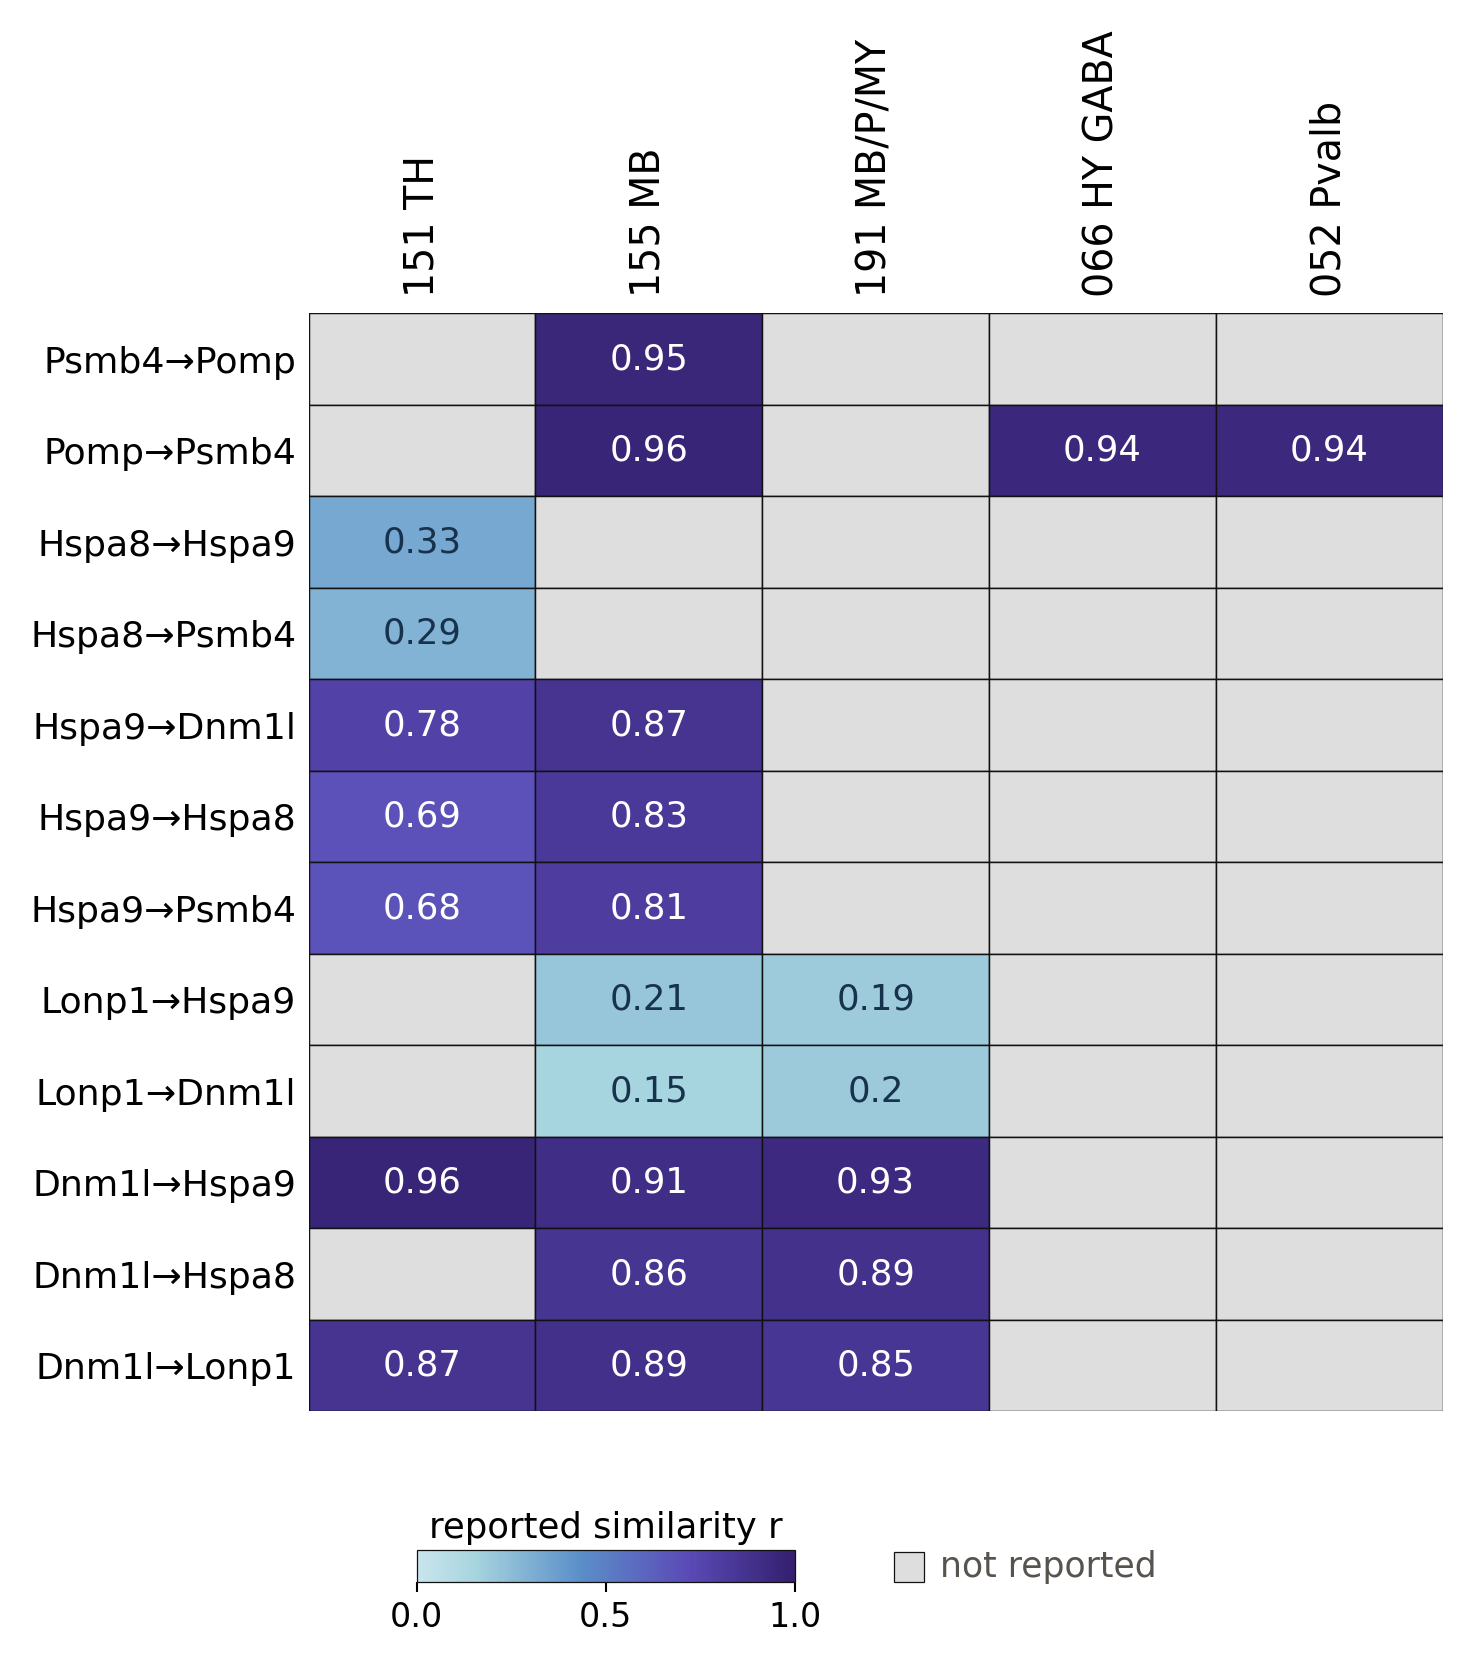

In [10]:
ROW_ORDER = ['Psmb4→Pomp', 'Pomp→Psmb4', 'Hspa8→Hspa9', 'Hspa8→Psmb4', 'Hspa9→Dnm1l', 'Hspa9→Hspa8', 'Hspa9→Psmb4', 'Lonp1→Hspa9', 'Lonp1→Dnm1l', 'Dnm1l→Hspa9', 'Dnm1l→Hspa8', 'Dnm1l→Lonp1']
matrix = values.pivot(index='relationship', columns='cell_type', values='similarity_r').reindex(index=ROW_ORDER, columns=CELL_TYPES)
FIG_W_IN = FIG_H_IN = 6.0
fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN))
base_cmap = LinearSegmentedColormap.from_list('report_similarity', ['#e8f3f8', '#a8d5df', '#5b8fc9', '#5b4bb7', '#34206f'])
heatmap_cmap = LinearSegmentedColormap.from_list('report_similarity_mapped', [base_cmap(x) for x in np.linspace(0.12, 1.0, 256)])
norm = Normalize(vmin=0, vmax=1)
for y, relationship in enumerate(ROW_ORDER):
    for x, cell_type in enumerate(CELL_TYPES):
        value = matrix.loc[relationship, cell_type]
        missing = pd.isna(value)
        face = '#dedede' if missing else heatmap_cmap(norm(value))
        ax.add_patch(Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor=face, edgecolor='#111111', linewidth=0.35))
        if not missing:
            ax.text(x, y, f'{value:.2g}', ha='center', va='center', fontsize=8.5, color='white' if value >= 0.52 else '#17324d', weight='normal')
ax.set_xlim(-0.5, len(CELL_TYPES) - 0.5)
ax.set_ylim(len(ROW_ORDER) - 0.5, -0.5)
ax.set_xticks(range(len(CELL_TYPES)), CELL_TYPES, rotation=90, ha='center', va='bottom')
ax.xaxis.tick_top()
ax.set_yticks(range(len(ROW_ORDER)), ROW_ORDER)
ax.tick_params(axis='x', labelsize=9.5, length=0, pad=4)
ax.tick_params(axis='y', labelsize=8.7, length=0, pad=3)
for spine in ax.spines.values():
    spine.set_visible(False)
cax = fig.add_axes([0.4, 0.075, 0.21, 0.018])
colorbar = fig.colorbar(ScalarMappable(norm=norm, cmap=heatmap_cmap), cax=cax, orientation='horizontal', ticks=[0, 0.5, 1.0])
colorbar.ax.tick_params(labelsize=8, length=2.5, width=0.5, pad=2)
colorbar.outline.set_edgecolor('#111111')
colorbar.outline.set_linewidth(0.3)
cax.set_title('reported similarity r', fontsize=8.5, pad=3)
missing_key = Rectangle((0.665, 0.075), 0.017, 0.017, transform=fig.transFigure, facecolor='#dedede', edgecolor='#111111', linewidth=0.3, clip_on=False)
fig.add_artist(missing_key)
fig.text(0.691, 0.0835, 'not reported', fontsize=8.3, va='center', color='#57534e')
fig.subplots_adjust(left=0.34, right=0.97, bottom=0.17, top=0.78)
plt.show()

## Figure 1E — SWI/SNF synaptic and excitability program

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib as mpl
import matplotlib.pyplot as plt
OUT = ROOT / 'src/manuscript_figures/fig1/e'
DEG = DEG_PATH
GROUP = '151 TH Prkcd Grin2c Glut'
ORDER = ['Smarcb1', 'Smarcc2', 'Arid2', 'Arid1a']
COLORS = {'Smarcb1': '#5B6FB5', 'Smarcc2': '#59A7A0', 'Arid2': '#E39A45', 'Arid1a': '#C76B82'}
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42})

### Explicit-value view

In [12]:
explicit = pd.read_csv(OUT / 'report_defined_genes.csv')
explicit = explicit[explicit.module.eq('Synaptic transmission / excitability')][['perturbation', 'gene', 'logFC', 'report_label']].copy()
explicit.groupby('perturbation').size().reindex(ORDER)

perturbation
Smarcb1    4
Smarcc2    6
Arid2      3
Arid1a     6
dtype: int64

### Full module view

In [13]:
report_modules = {'Smarcb1': {'Mature synaptic identity / transmission': ['Prkcd', 'Grin2c', 'Grm1', 'Gabra4', 'Begain', 'Shank1', 'Lrrtm1', 'Slc6a7', 'Atp1b2', 'Kcnk4'], 'Dendritic / NMDA-linked signaling': ['Tiam1']}, 'Smarcc2': {'Synapse / cell junction': ['Nlgn2', 'Agrn', 'Lrrtm1', 'L1cam', 'Begain'], 'Membrane excitability / ion handling': ['Cnih3', 'Cacnb2', 'Hcn4', 'P2rx4', 'Asic2', 'Atp2b1'], 'Neurite / synapse organization': ['Tiam1', 'Prkcd'], 'Compensatory synaptic remodeling': ['Grin3a', 'Grm5']}, 'Arid2': {'Membrane signaling / excitability': ['Kcnj9', 'Gpr4', 'Gpr153', 'Pde4a', 'Map2k2', 'Prkcd'], 'Synaptic handling / vesicle trafficking': ['Stxbp2', 'Nsg1', 'Gria2', 'Ece2']}, 'Arid1a': {'Synaptic / PSD': ['Begain', 'Lrrc7', 'Clstn2', 'Mpp2'], 'Excitability / signaling': ['Kcnq2', 'Prkcb', 'Rasa4', 'Ppp2r5d', 'Adora1']}}
rows = []
for perturbation, modules in report_modules.items():
    for module, genes in modules.items():
        rows += [(perturbation, g, module) for g in genes]
membership = pd.DataFrame(rows, columns=['perturbation', 'gene', 'report_module']).drop_duplicates(['perturbation', 'gene'])
tab = pq.read_table(DEG, columns=['names', 'gene_target', 'logfoldchanges', 'pvals_adj'], filters=[('group_name', '=', GROUP), ('gene_target', 'in', ORDER)])
raw = tab.to_pandas().rename(columns={'names': 'gene', 'gene_target': 'perturbation', 'logfoldchanges': 'logFC', 'pvals_adj': 'FDR'})
expanded = membership.merge(raw, on=['perturbation', 'gene'], how='left', validate='one_to_one')
assert expanded.logFC.notna().all()
expanded.groupby('perturbation').size().reindex(ORDER)

perturbation
Smarcb1    11
Smarcc2    15
Arid2      10
Arid1a      9
dtype: int64

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


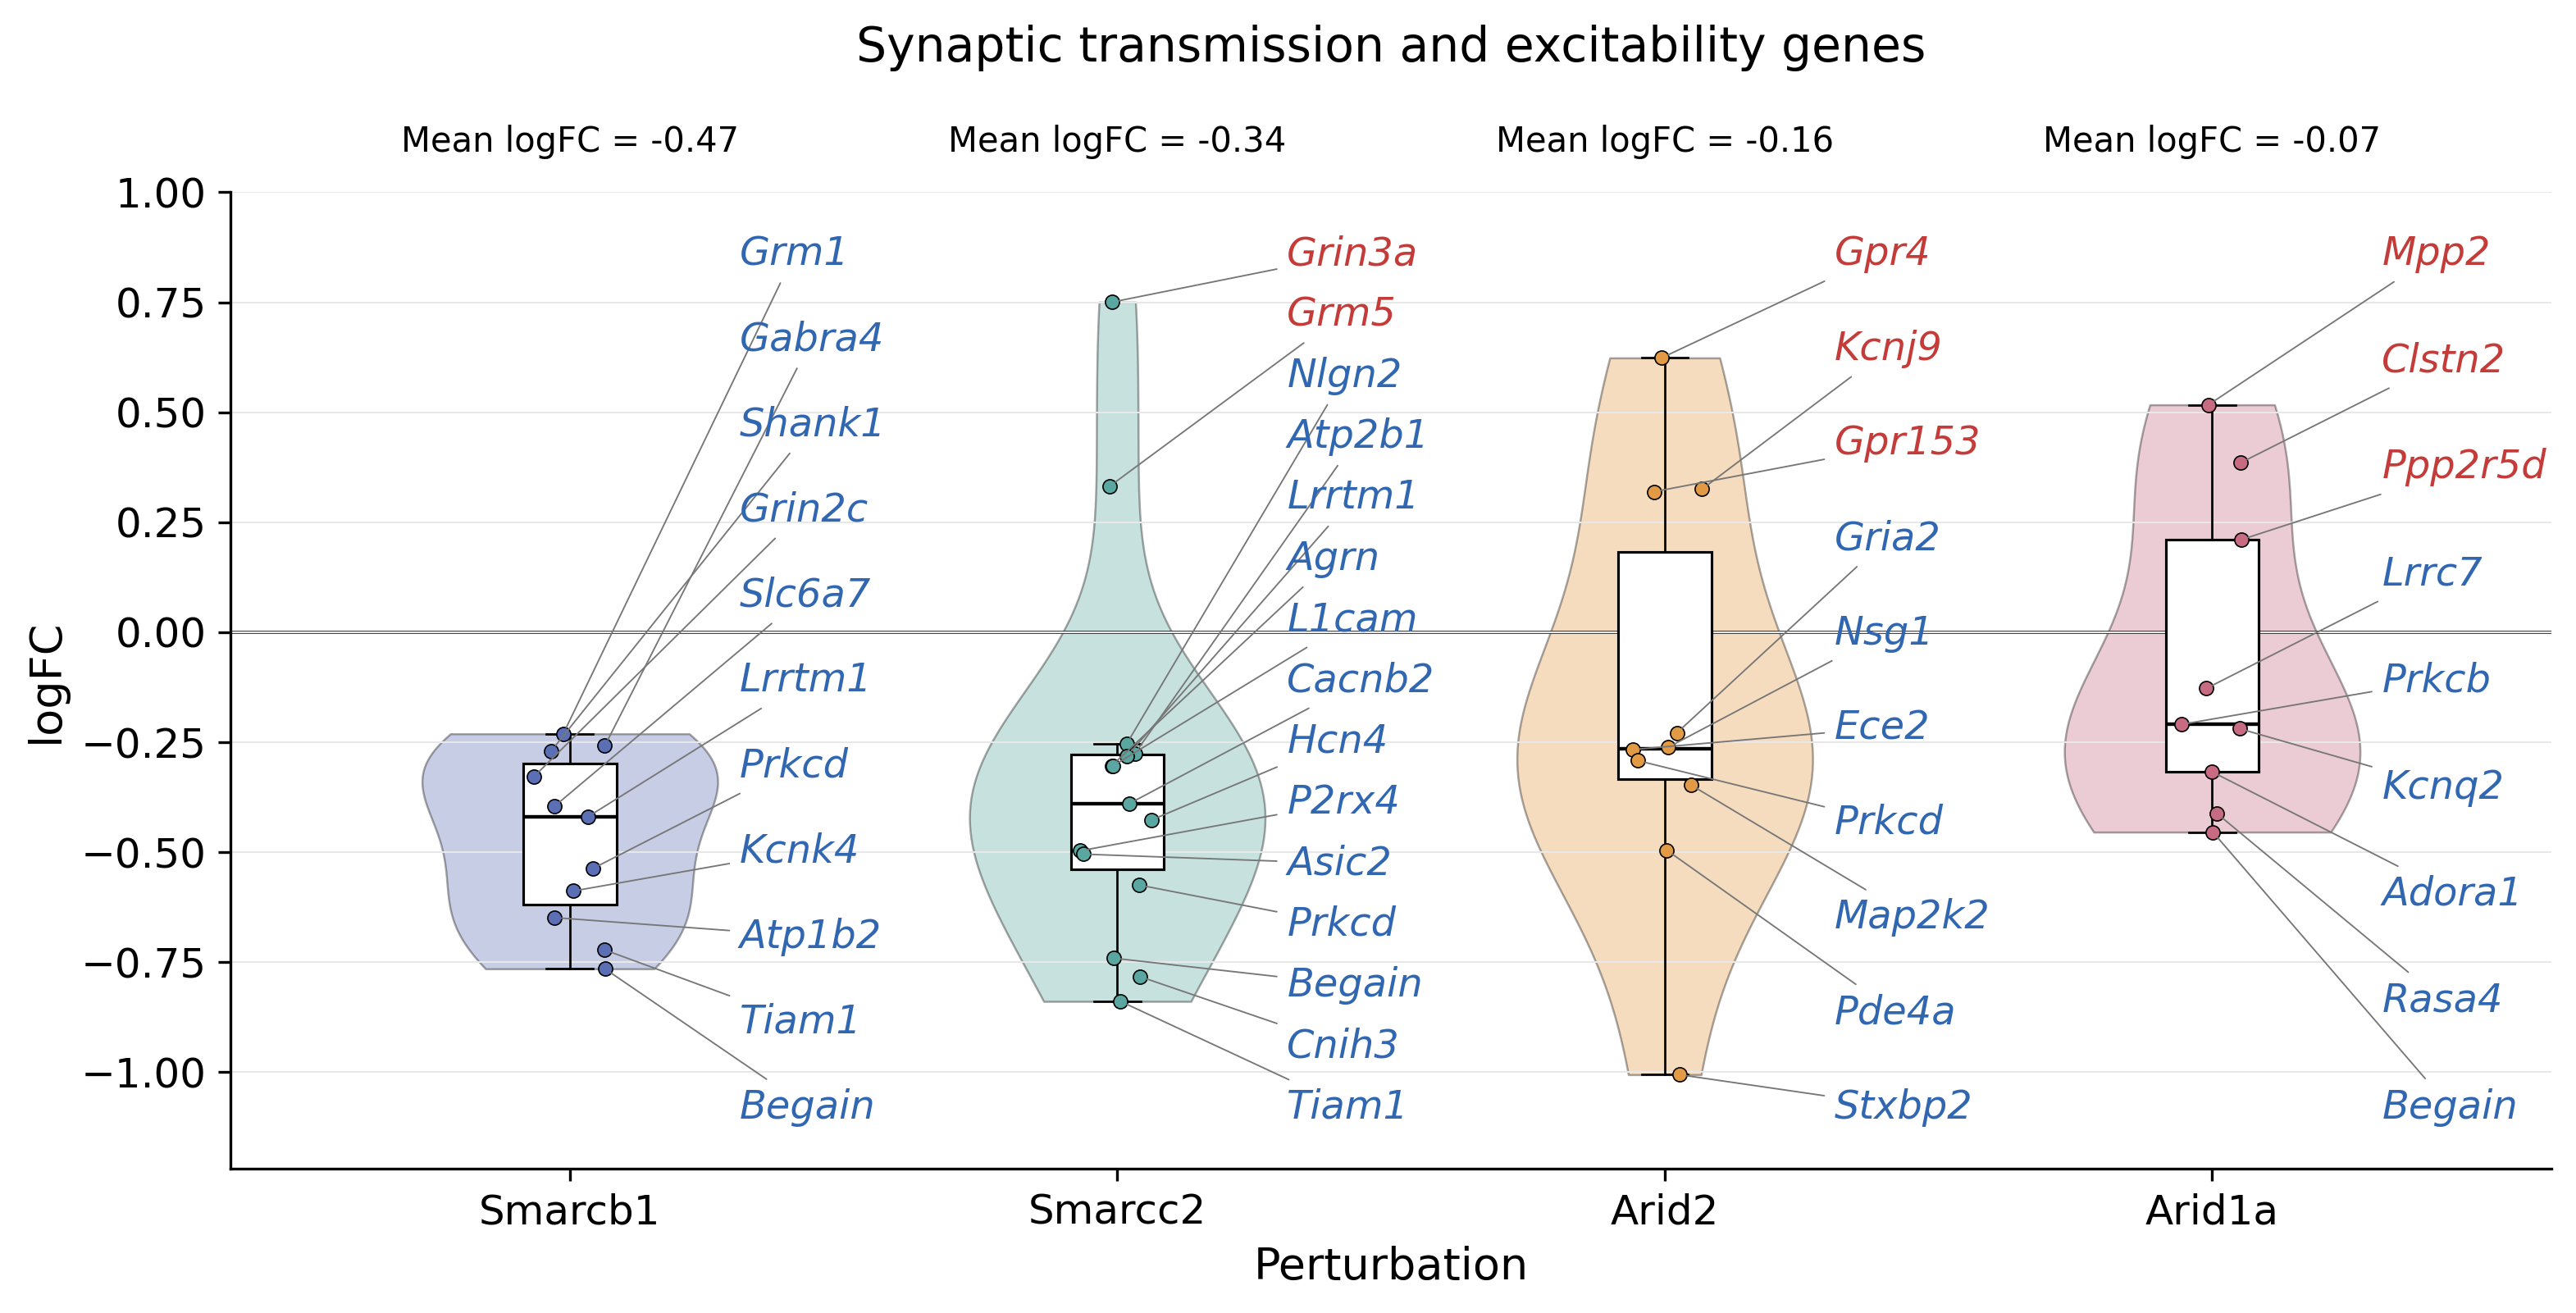

In [14]:
def plot_violin(data, title, stem):
    fig, ax = plt.subplots(figsize=(10.5, 5.3))
    rng = np.random.default_rng(19)
    for x, perturbation in enumerate(ORDER):
        d = data[data.perturbation.eq(perturbation)].sort_values('logFC', ascending=False).copy()
        vals = d.logFC.to_numpy()
        vp = ax.violinplot(vals, positions=[x], widths=0.54, showmeans=False, showmedians=False, showextrema=False)
        for body in vp['bodies']:
            body.set_facecolor(COLORS[perturbation])
            body.set_edgecolor('black')
            body.set_linewidth(0.6)
            body.set_alpha(0.34)
        ax.boxplot(vals, positions=[x], widths=0.17, patch_artist=True, showfliers=False, boxprops=dict(facecolor='white', edgecolor='black', linewidth=0.75), medianprops=dict(color='black', linewidth=1.05), whiskerprops=dict(color='black', linewidth=0.65), capprops=dict(color='black', linewidth=0.65))
        jitter = rng.uniform(-0.075, 0.075, len(vals))
        px = x + jitter
        ax.scatter(px, vals, s=17, color=COLORS[perturbation], edgecolor='black', linewidth=0.4, zorder=5)
        label_x = x + 0.31
        label_y = np.linspace(0.86, -1.08, len(d)) if len(d) > 1 else vals
        for (_, row), ly in zip(d.iterrows(), label_y):
            idx = d.index.get_loc(row.name)
            gene_color = '#C43C39' if row.logFC > 0 else '#3167B1'
            ax.annotate(row.gene, xy=(px[idx], row.logFC), xytext=(label_x, ly), ha='left', va='center', fontsize=11.5, fontstyle='italic', color=gene_color, arrowprops=dict(arrowstyle='-', color='#777777', lw=0.45, shrinkA=1, shrinkB=2), annotation_clip=False, zorder=6)
        ax.text(x, 1.075, f'Mean logFC = {vals.mean():+.2f}', ha='center', va='bottom', fontsize=10, clip_on=False)
    ax.axhline(0, color='#222222', lw=0.9, zorder=1)
    ax.set_xticks(range(4), ORDER)
    ax.set_xlim(-0.62, 3.62)
    ax.set_ylim(-1.22, 1.0)
    ax.set_ylabel('logFC', fontsize=13)
    ax.set_xlabel('Perturbation', fontsize=13)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_title(title, loc='center', fontsize=14, y=1.12, pad=4)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#E8E8E8', lw=0.5, zorder=0)
    fig.tight_layout(pad=0.55)
    for ext in ['pdf']:
        kw = {'bbox_inches': 'tight', 'pad_inches': 0.03}
        if ext == 'png':
            kw['dpi'] = 300
    plt.show()
plot_violin(expanded, 'Synaptic transmission and excitability genes', 'E2_SWI_SNF_synaptic_excitability_all_genes')

## Figure 1E — Grin2a/Grin2b restricted-signature correlation

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
OUT = ROOT / 'src/manuscript_figures/fig1/e'
DEG = DEG_PATH
GROUP = '007 L2-3 IT CTX Glut'
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42})

In [16]:
tab = pq.read_table(DEG, columns=['names', 'gene_target', 'scores', 'logfoldchanges', 'pvals_adj'], filters=[('group_name', '=', GROUP), ('gene_target', 'in', ['Grin2a', 'Grin2b'])])
raw = tab.to_pandas()
b = raw[raw.gene_target.eq('Grin2b') & raw.pvals_adj.lt(0.05) & raw.logfoldchanges.abs().ge(0.25)][['names', 'logfoldchanges', 'pvals_adj']].copy()
assert len(b) == 47, f'Expected 47 genes, found {len(b)}'
b.columns = ['gene', 'Grin2b_logFC', 'Grin2b_FDR']
a = raw[raw.gene_target.eq('Grin2a')][['names', 'logfoldchanges', 'pvals_adj']].copy()
a.columns = ['gene', 'Grin2a_logFC', 'Grin2a_FDR']
plot_df = b.merge(a, on='gene', validate='one_to_one')
r, p = pearsonr(plot_df.Grin2a_logFC, plot_df.Grin2b_logFC)
print(f'n={len(plot_df)}; Pearson r={r:.8f}; p={p:.3g}')
assert np.isclose(r, -0.63, atol=0.005)

n=47; Pearson r=-0.62995040; p=2.09e-06


In [17]:
pathway_genes = {'Activity / plasticity': {'Vgf', 'Nr4a1', 'Bdnf', 'Npas4', 'Nptx2', 'Ptgs2', 'Arc', 'Egr1'}, 'Vesicle priming / docking': {'Unc13a', 'Unc13b', 'Rims1', 'Erc2', 'Rph3a', 'Tspoap1'}, 'Synapse / postsynapse': {'Kcnv1', 'Sorcs3', 'Dlgap2', 'Nptxr', 'Cabp1'}, 'Structural remodeling / membrane': {'Stmn1', 'Celsr2', 'Adamts2', 'Zdhhc2'}}

def assign_pathway(gene):
    for pathway, genes in pathway_genes.items():
        if gene in genes:
            return pathway
    return 'Other significant DEG'
plot_df['pathway'] = plot_df.gene.map(assign_pathway)
plot_df.groupby('pathway').size()

pathway
Activity / plasticity                1
Other significant DEG               31
Structural remodeling / membrane     4
Synapse / postsynapse                5
Vesicle priming / docking            6
dtype: int64

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


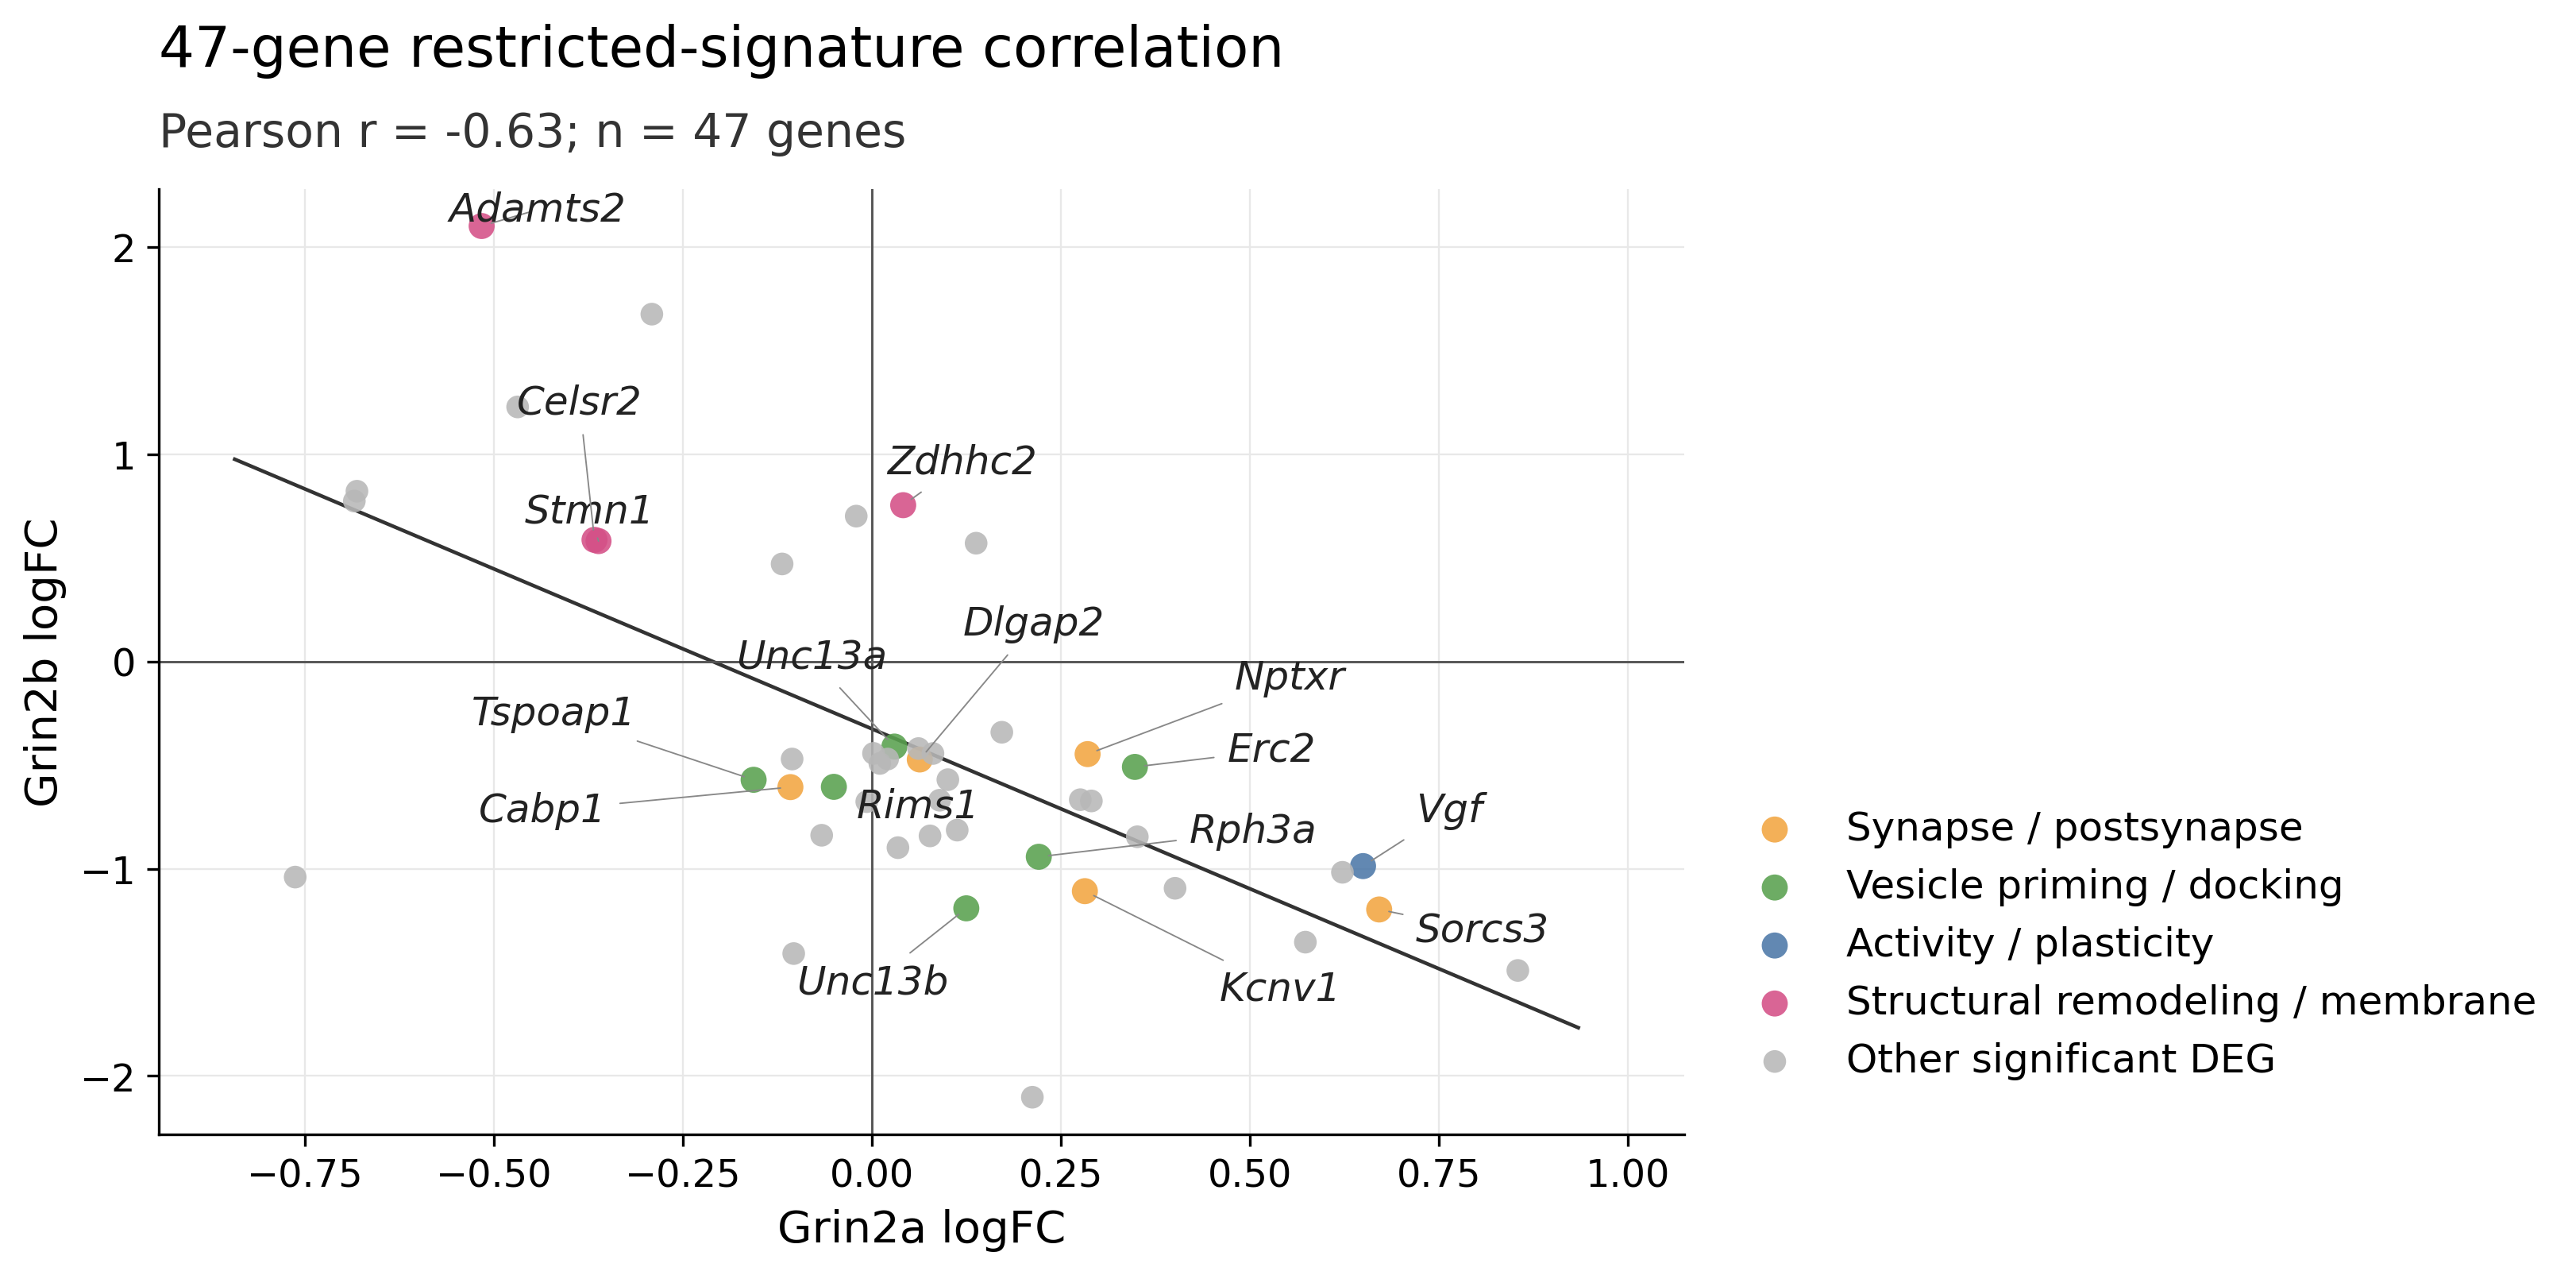

In [18]:
colors = {'Activity / plasticity': '#4C78A8', 'Vesicle priming / docking': '#59A14F', 'Synapse / postsynapse': '#F2A541', 'Structural remodeling / membrane': '#D45087', 'Other significant DEG': '#B8B8B8'}
fig, ax = plt.subplots(figsize=(10.5, 6.2))
draw_order = ['Synapse / postsynapse', 'Vesicle priming / docking', 'Activity / plasticity', 'Structural remodeling / membrane', 'Other significant DEG']
for pathway in draw_order:
    d = plot_df[plot_df.pathway.eq(pathway)]
    ax.scatter(d.Grin2a_logFC, d.Grin2b_logFC, s=47 if pathway.startswith('Other') else 62, color=colors[pathway], edgecolor='none', linewidth=0, alpha=0.88, label=pathway, zorder=3)
coef = np.polyfit(plot_df.Grin2a_logFC, plot_df.Grin2b_logFC, 1)
xx = np.linspace(plot_df.Grin2a_logFC.min() - 0.08, plot_df.Grin2a_logFC.max() + 0.08, 100)
ax.plot(xx, np.polyval(coef, xx), color='#333333', lw=1.1, zorder=2)
ax.axhline(0, color='#555555', lw=0.7)
ax.axvline(0, color='#555555', lw=0.7)
ax.set_box_aspect(0.62)
label_genes = set().union(*pathway_genes.values()) & set(plot_df.gene)
ax.set_xlim(plot_df.Grin2a_logFC.min() - 0.18, plot_df.Grin2a_logFC.max() + 0.22)
ax.set_ylim(plot_df.Grin2b_logFC.min() - 0.18, plot_df.Grin2b_logFC.max() + 0.18)
label_positions = {'Adamts2': (-0.56, 2.18), 'Celsr2': (-0.47, 1.25), 'Stmn1': (-0.46, 0.72), 'Zdhhc2': (0.02, 0.96), 'Tspoap1': (-0.53, -0.25), 'Cabp1': (-0.52, -0.72), 'Unc13a': (-0.18, 0.02), 'Rims1': (-0.02, -0.7), 'Unc13b': (-0.1, -1.55), 'Dlgap2': (0.12, 0.18), 'Nptxr': (0.48, -0.08), 'Erc2': (0.47, -0.43), 'Rph3a': (0.42, -0.82), 'Kcnv1': (0.46, -1.58), 'Vgf': (0.72, -0.72), 'Sorcs3': (0.72, -1.3)}
for row in plot_df[plot_df.gene.isin(label_genes)].itertuples():
    tx, ty = label_positions[row.gene]
    ax.annotate(row.gene, xy=(row.Grin2a_logFC, row.Grin2b_logFC), xytext=(tx, ty), textcoords='data', fontsize=12, fontstyle='italic', color='#222222', ha='left', va='center', arrowprops=dict(arrowstyle='-', color='#888888', lw=0.45, shrinkA=2, shrinkB=3))
ax.set_xlabel('Grin2a logFC', fontsize=13.5)
ax.set_ylabel('Grin2b logFC', fontsize=13.5)
ax.set_title('47-gene restricted-signature correlation', loc='left', fontsize=17, y=1.105, pad=7)
ax.text(0, 1.035, f'Pearson r = {r:.2f}; n = {len(plot_df)} genes', transform=ax.transAxes, ha='left', va='bottom', fontsize=14, color='#333333', clip_on=False)
ax.tick_params(labelsize=11.5)
ax.grid(color='#E8E8E8', lw=0.55, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=12, loc='lower left', bbox_to_anchor=(1.01, 0.02))
fig.tight_layout()
for ext in ['pdf']:
    kw = {'bbox_inches': 'tight', 'pad_inches': 0.04}
    if ext == 'png':
        kw['dpi'] = 300
plt.show()

## Figure 1F — proteostasis response analyses

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
OUT = ROOT / 'src/manuscript_figures/fig1/f'
DEG = DEG_PATH
TARGETS = ['Psmb4', 'Pomp', 'Hspa5', 'Hspa8', 'Hspa9', 'Lonp1', 'Opa1', 'Dnm1l']
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42})

### 1. Coupled loss of neuronal-maintenance genes

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


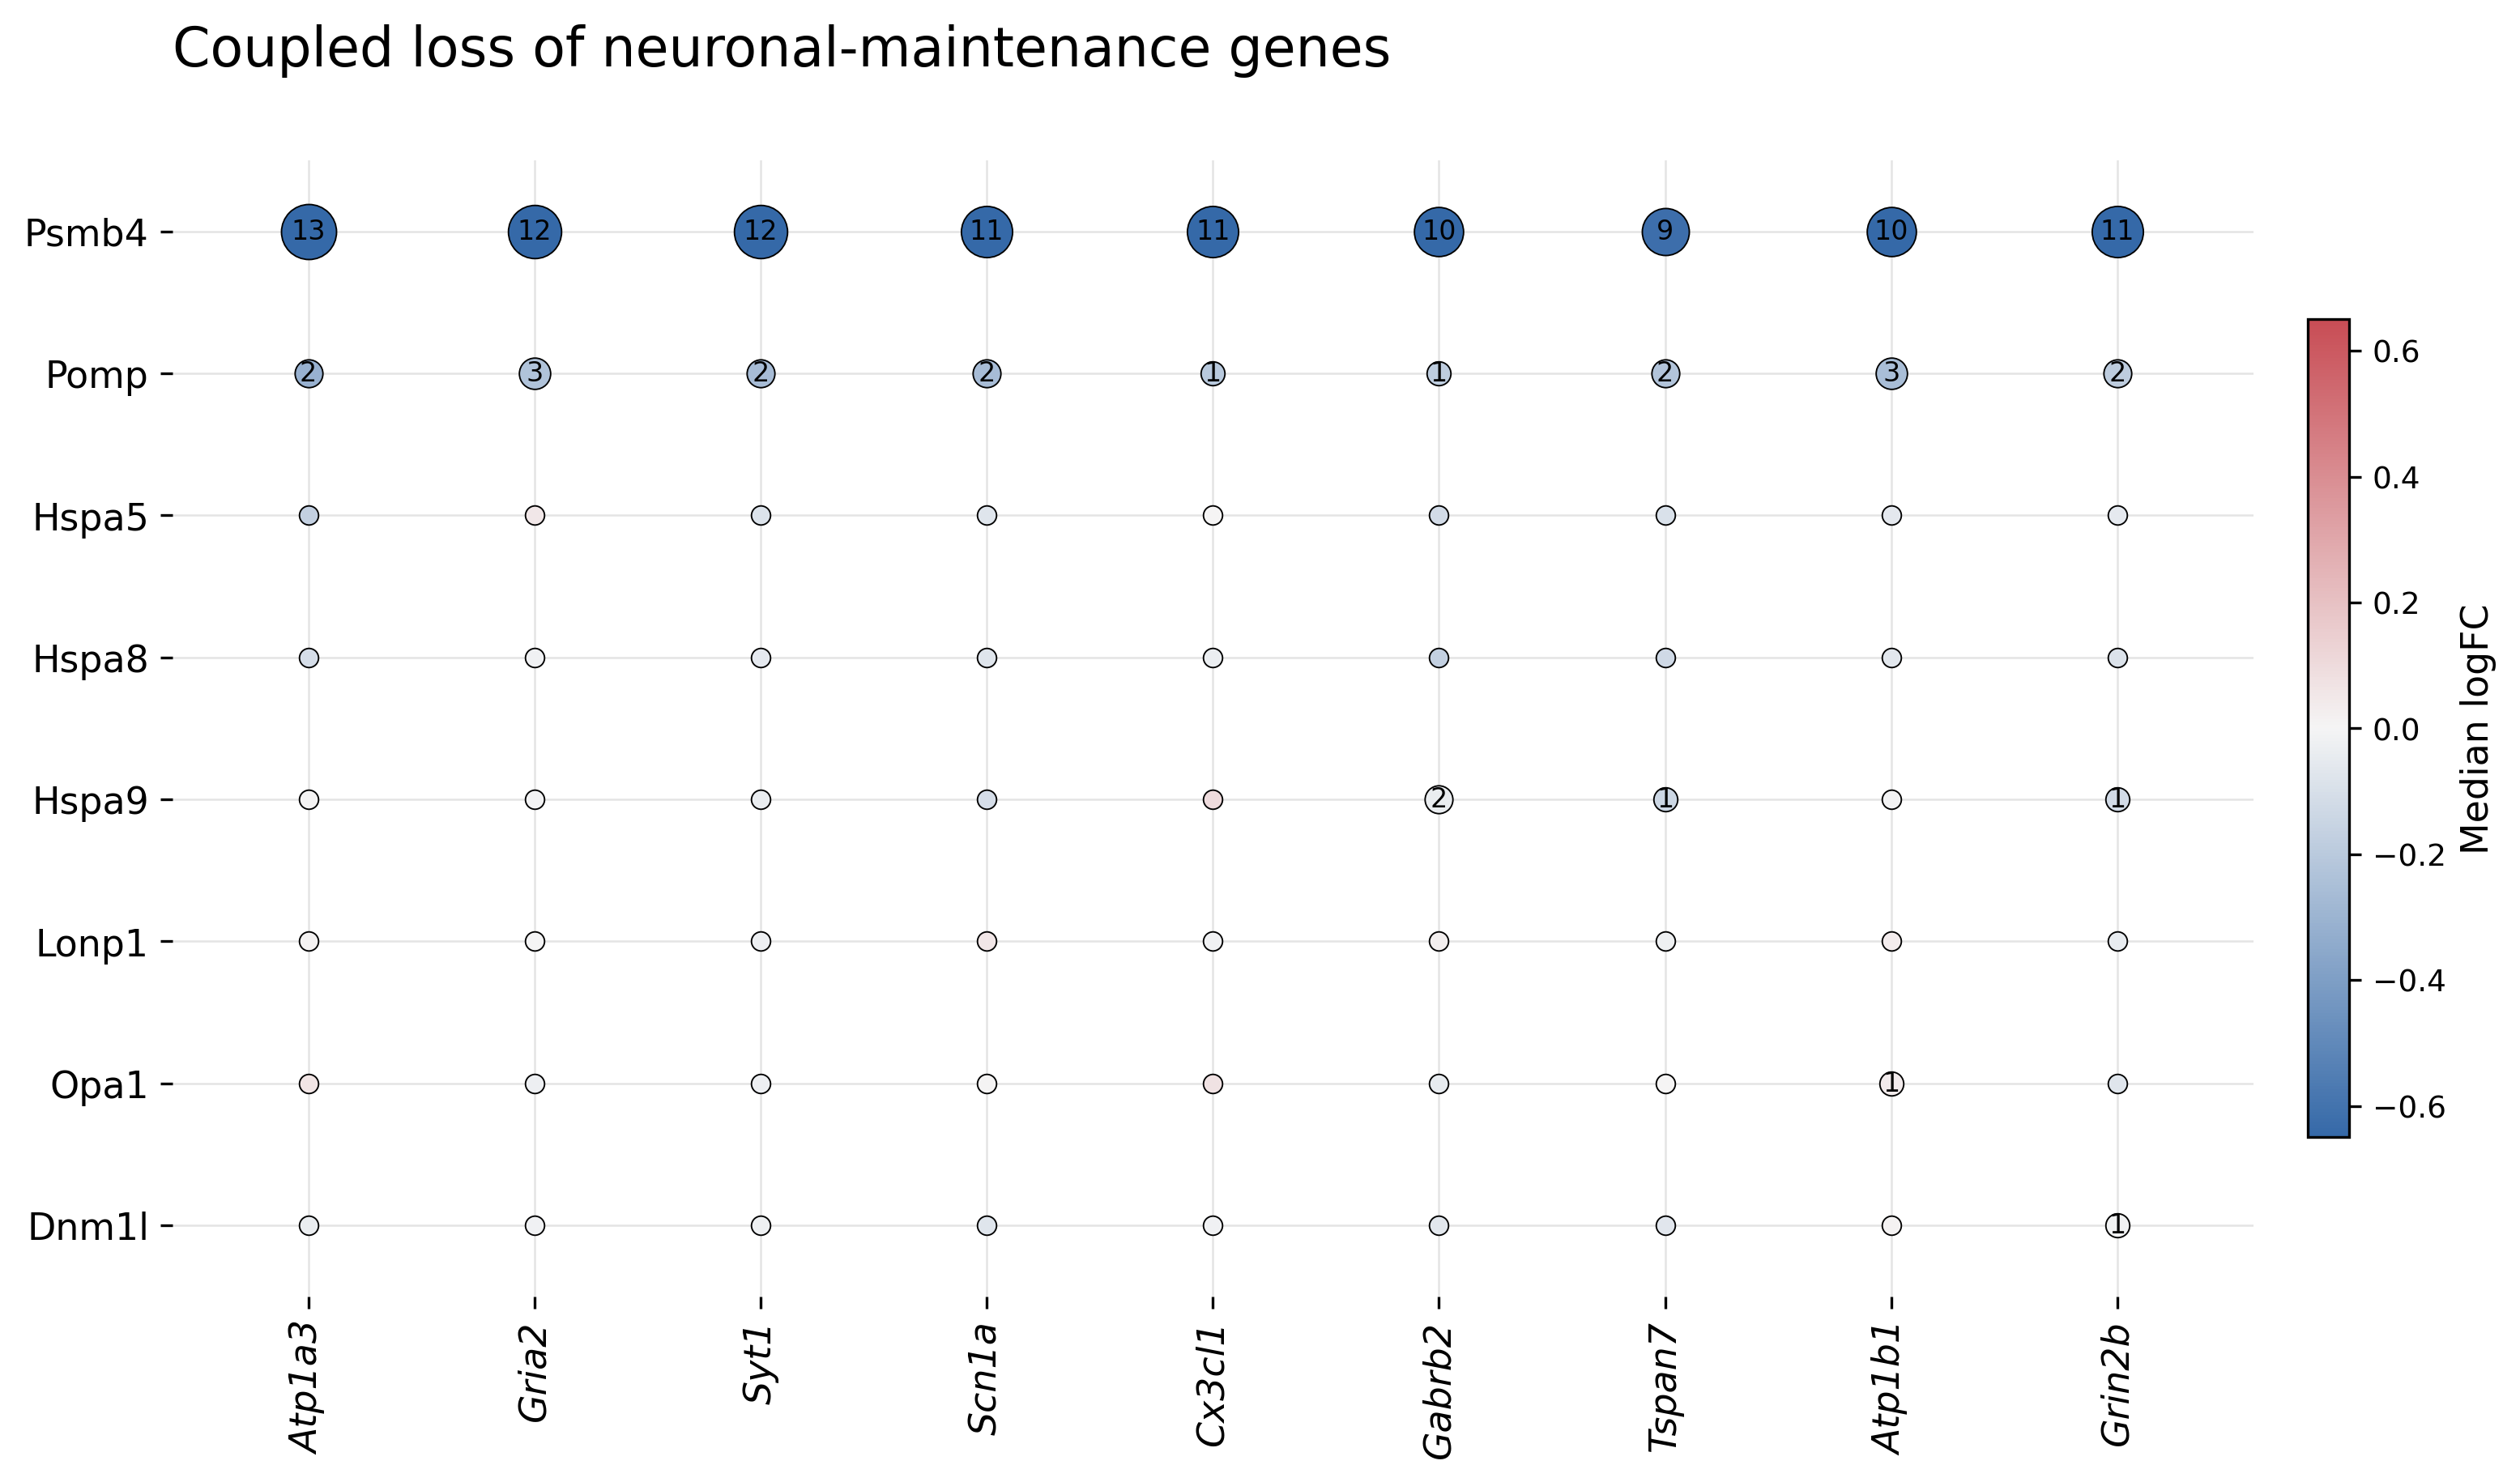

In [20]:
genes = ['Atp1a3', 'Gria2', 'Syt1', 'Scn1a', 'Cx3cl1', 'Gabrb2', 'Tspan7', 'Atp1b1', 'Grin2b']
tab = pq.read_table(DEG, columns=['names', 'gene_target', 'group_name', 'logfoldchanges', 'pvals_adj'], filters=[('gene_target', 'in', TARGETS), ('names', 'in', genes)])
raw = tab.to_pandas().rename(columns={'names': 'gene', 'gene_target': 'perturbation', 'logfoldchanges': 'logFC', 'pvals_adj': 'FDR'})
summary = raw.groupby(['perturbation', 'gene']).agg(median_logFC=('logFC', 'median'), fdr_groups=('FDR', lambda x: int((x < 0.05).sum())), tested_groups=('group_name', 'nunique')).reset_index()
fig, ax = plt.subplots(figsize=(10.5, 6.2))
cmap = LinearSegmentedColormap.from_list('lfc', ['#3569A8', '#F5F5F5', '#C84D55'])
norm = Normalize(-0.65, 0.65)
for yi, t in enumerate(TARGETS):
    d = summary[summary.perturbation.eq(t)].set_index('gene').reindex(genes)
    for xi, g in enumerate(genes):
        row = d.loc[g]
        size = 32 + row.fdr_groups * 18
        ax.scatter(xi, yi, s=size, c=[cmap(norm(row.median_logFC))], edgecolor='black', linewidth=0.45)
        if row.fdr_groups > 0:
            ax.text(xi, yi, str(int(row.fdr_groups)), ha='center', va='center', fontsize=8)
ax.set_xticks(range(len(genes)), genes, rotation=90, fontstyle='italic', fontsize=11)
ax.set_yticks(range(len(TARGETS)), TARGETS, fontsize=11)
ax.invert_yaxis()
ax.set_xlim(-0.6, len(genes) - 0.4)
ax.set_ylim(len(TARGETS) - 0.5, -0.5)
ax.set_title('Coupled loss of neuronal-maintenance genes', loc='left', fontsize=16, pad=28)
ax.grid(color='#E4E4E4', lw=0.6)
ax.set_axisbelow(True)
ax.spines[:].set_visible(False)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.025, shrink=0.72)
cbar.set_label('Median logFC', fontsize=11)
cbar.ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()

### 2. Psmb4 three-part state transition

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


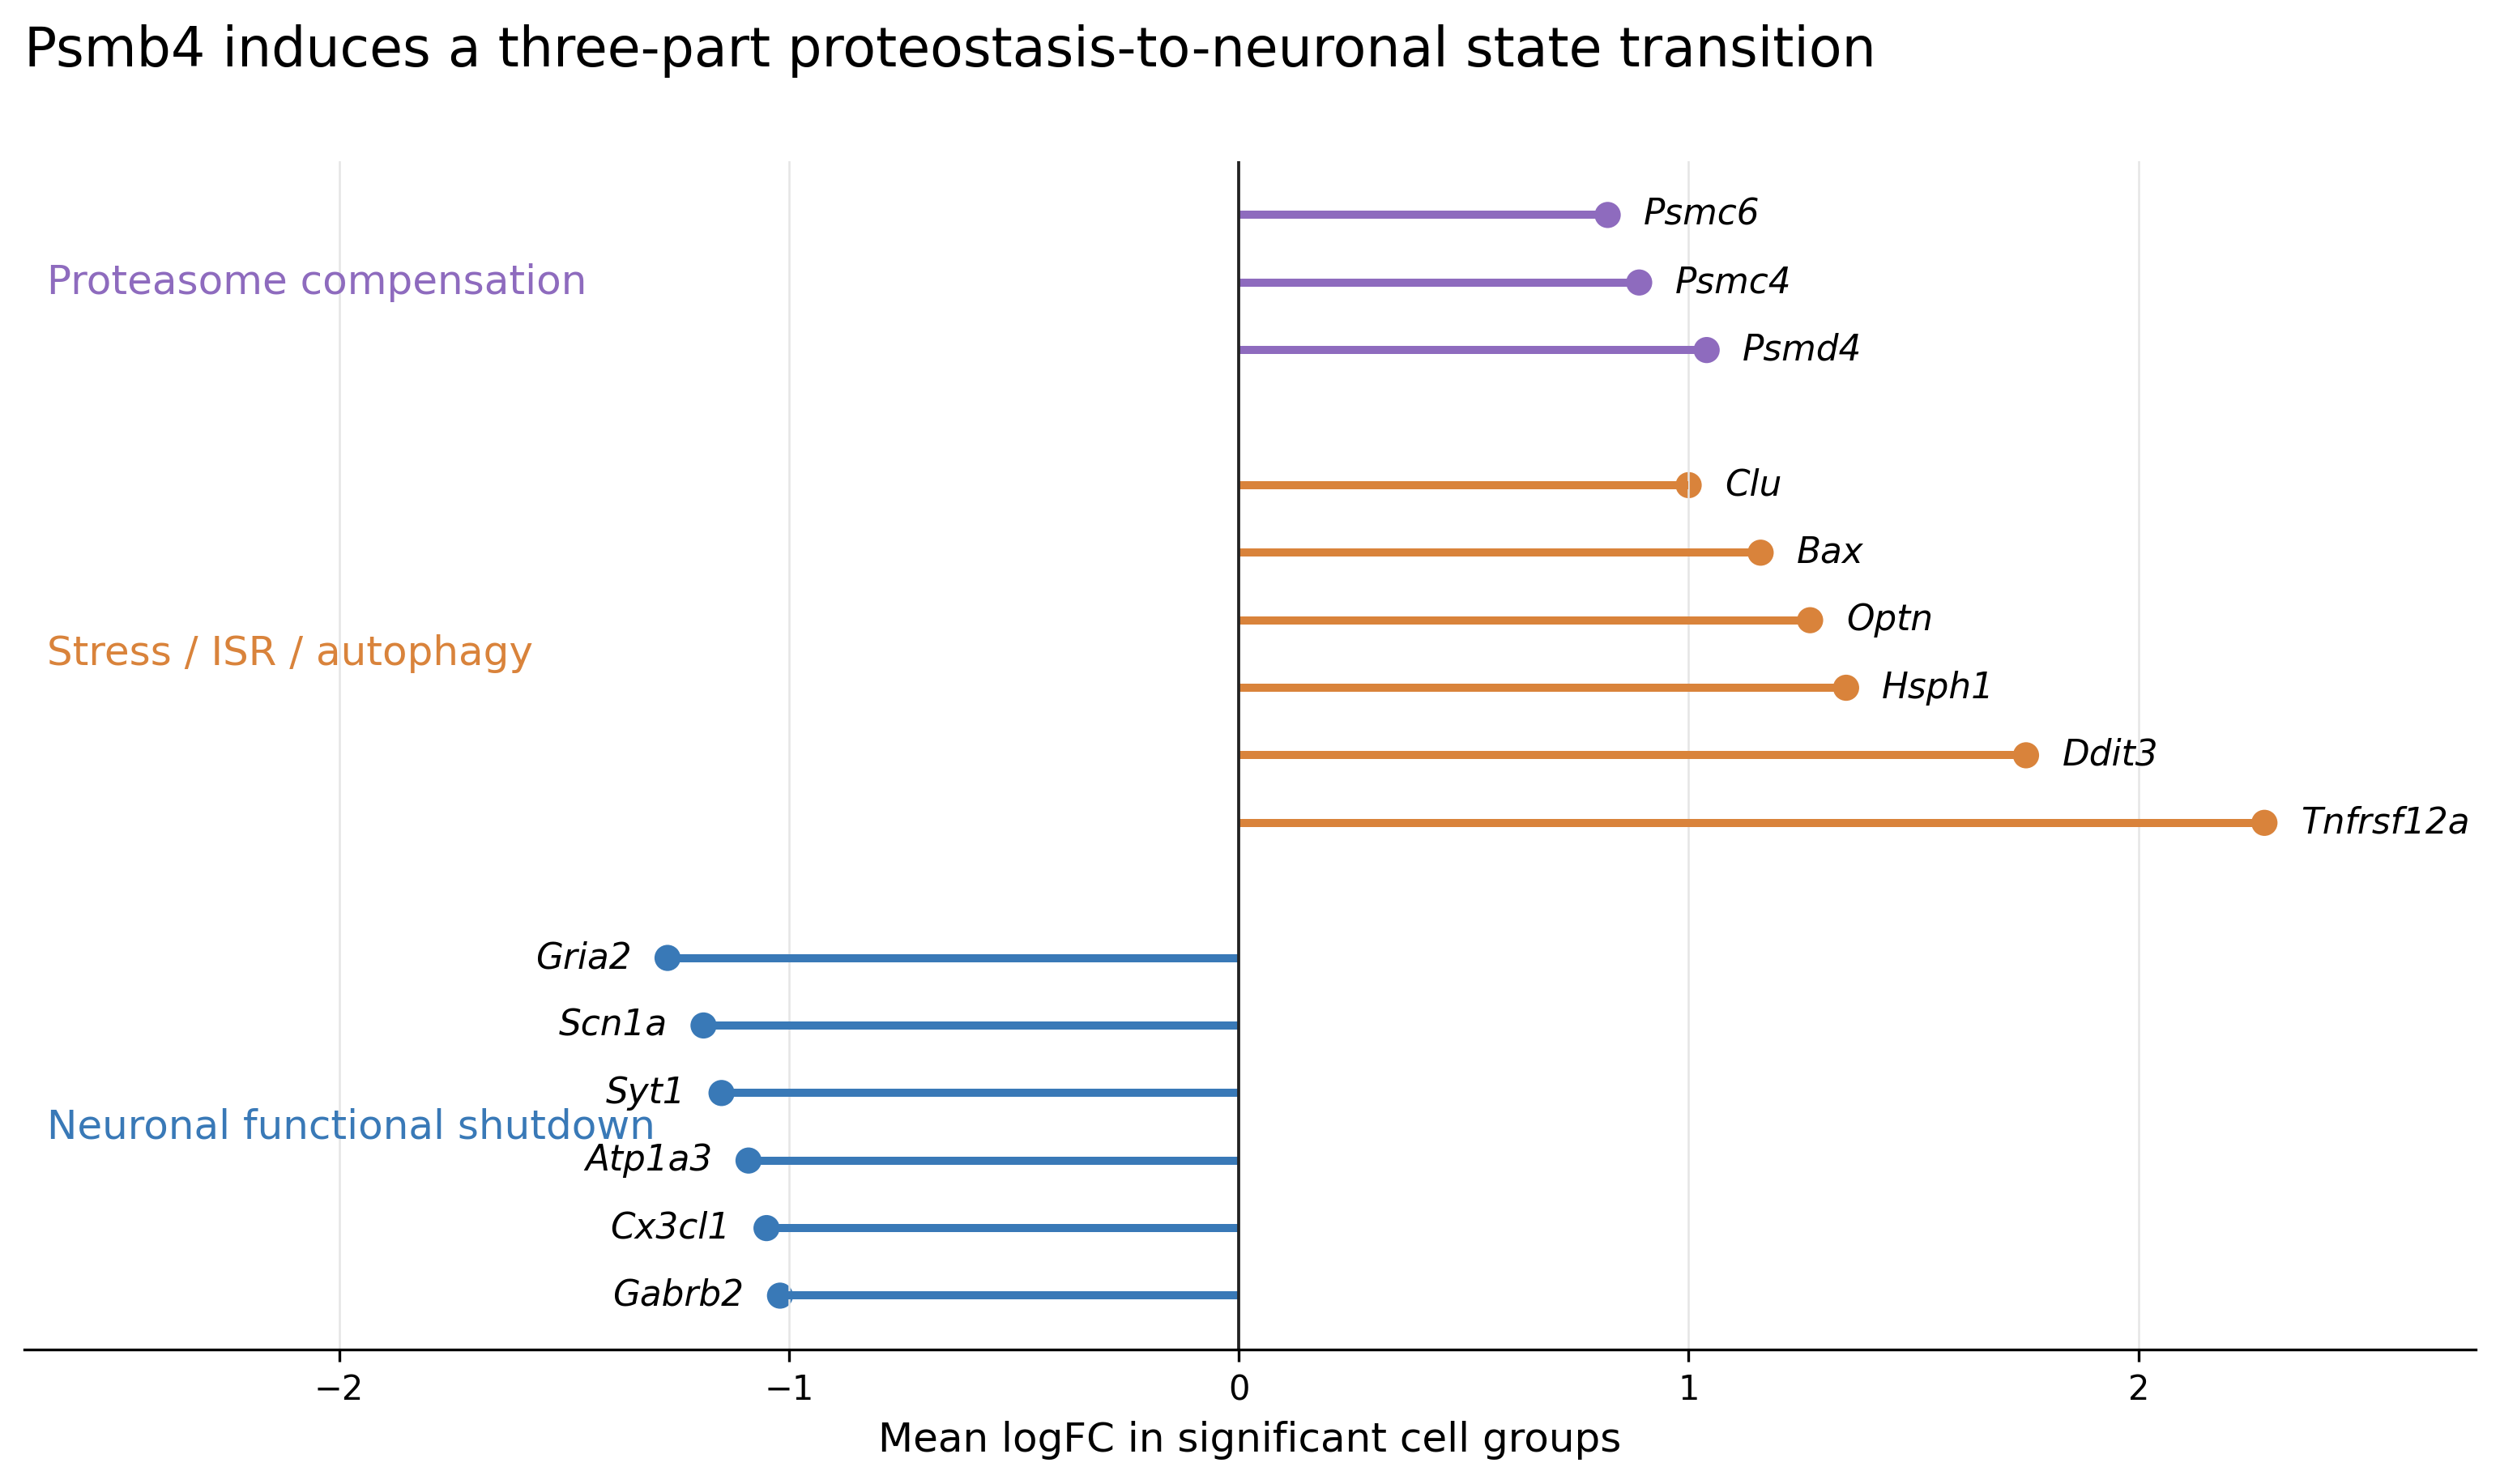

In [21]:
transition = pd.DataFrame([('Proteasome compensation', 'Psmc6', 0.82), ('Proteasome compensation', 'Psmd4', 1.04), ('Proteasome compensation', 'Psmc4', 0.89), ('Stress / ISR / autophagy', 'Hsph1', 1.35), ('Stress / ISR / autophagy', 'Ddit3', 1.75), ('Stress / ISR / autophagy', 'Optn', 1.27), ('Stress / ISR / autophagy', 'Tnfrsf12a', 2.28), ('Stress / ISR / autophagy', 'Clu', 1.0), ('Stress / ISR / autophagy', 'Bax', 1.16), ('Neuronal functional shutdown', 'Atp1a3', -1.09), ('Neuronal functional shutdown', 'Gria2', -1.27), ('Neuronal functional shutdown', 'Syt1', -1.15), ('Neuronal functional shutdown', 'Scn1a', -1.19), ('Neuronal functional shutdown', 'Cx3cl1', -1.05), ('Neuronal functional shutdown', 'Gabrb2', -1.02)], columns=['program', 'gene', 'mean_logFC_in_significant_groups'])
colors = {'Proteasome compensation': '#8E6BBE', 'Stress / ISR / autophagy': '#D9833B', 'Neuronal functional shutdown': '#3979B7'}
fig, ax = plt.subplots(figsize=(10.5, 6.2))
order = ['Proteasome compensation', 'Stress / ISR / autophagy', 'Neuronal functional shutdown']
y = 0
for program in order:
    d = transition[transition.program.eq(program)].sort_values('mean_logFC_in_significant_groups')
    ys = np.arange(y, y + len(d))
    vals = d.mean_logFC_in_significant_groups.to_numpy()
    ax.hlines(ys, 0, vals, color=colors[program], lw=2.4)
    ax.scatter(vals, ys, s=60, color=colors[program], edgecolor='none')
    for yy, row in zip(ys, d.itertuples()):
        ax.text(row.mean_logFC_in_significant_groups + (0.08 if row.mean_logFC_in_significant_groups > 0 else -0.08), yy, row.gene, ha='left' if row.mean_logFC_in_significant_groups > 0 else 'right', va='center', fontsize=10.5, fontstyle='italic')
    ax.text(-2.65, (ys[0] + ys[-1]) / 2, program, ha='left', va='center', fontsize=12, color=colors[program])
    y += len(d) + 1
ax.axvline(0, color='#222222', lw=0.9)
ax.invert_yaxis()
ax.set_yticks([])
ax.set_xlim(-2.7, 2.75)
ax.set_xlabel('Mean logFC in significant cell groups', fontsize=12)
ax.set_title('Psmb4 induces a three-part proteostasis-to-neuronal state transition', loc='left', fontsize=16, pad=28)
ax.grid(axis='x', color='#E5E5E5', lw=0.6)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(labelsize=10)
fig.tight_layout()
plt.show()

### 3. Shared mitochondrial mt-ISR neighborhood

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


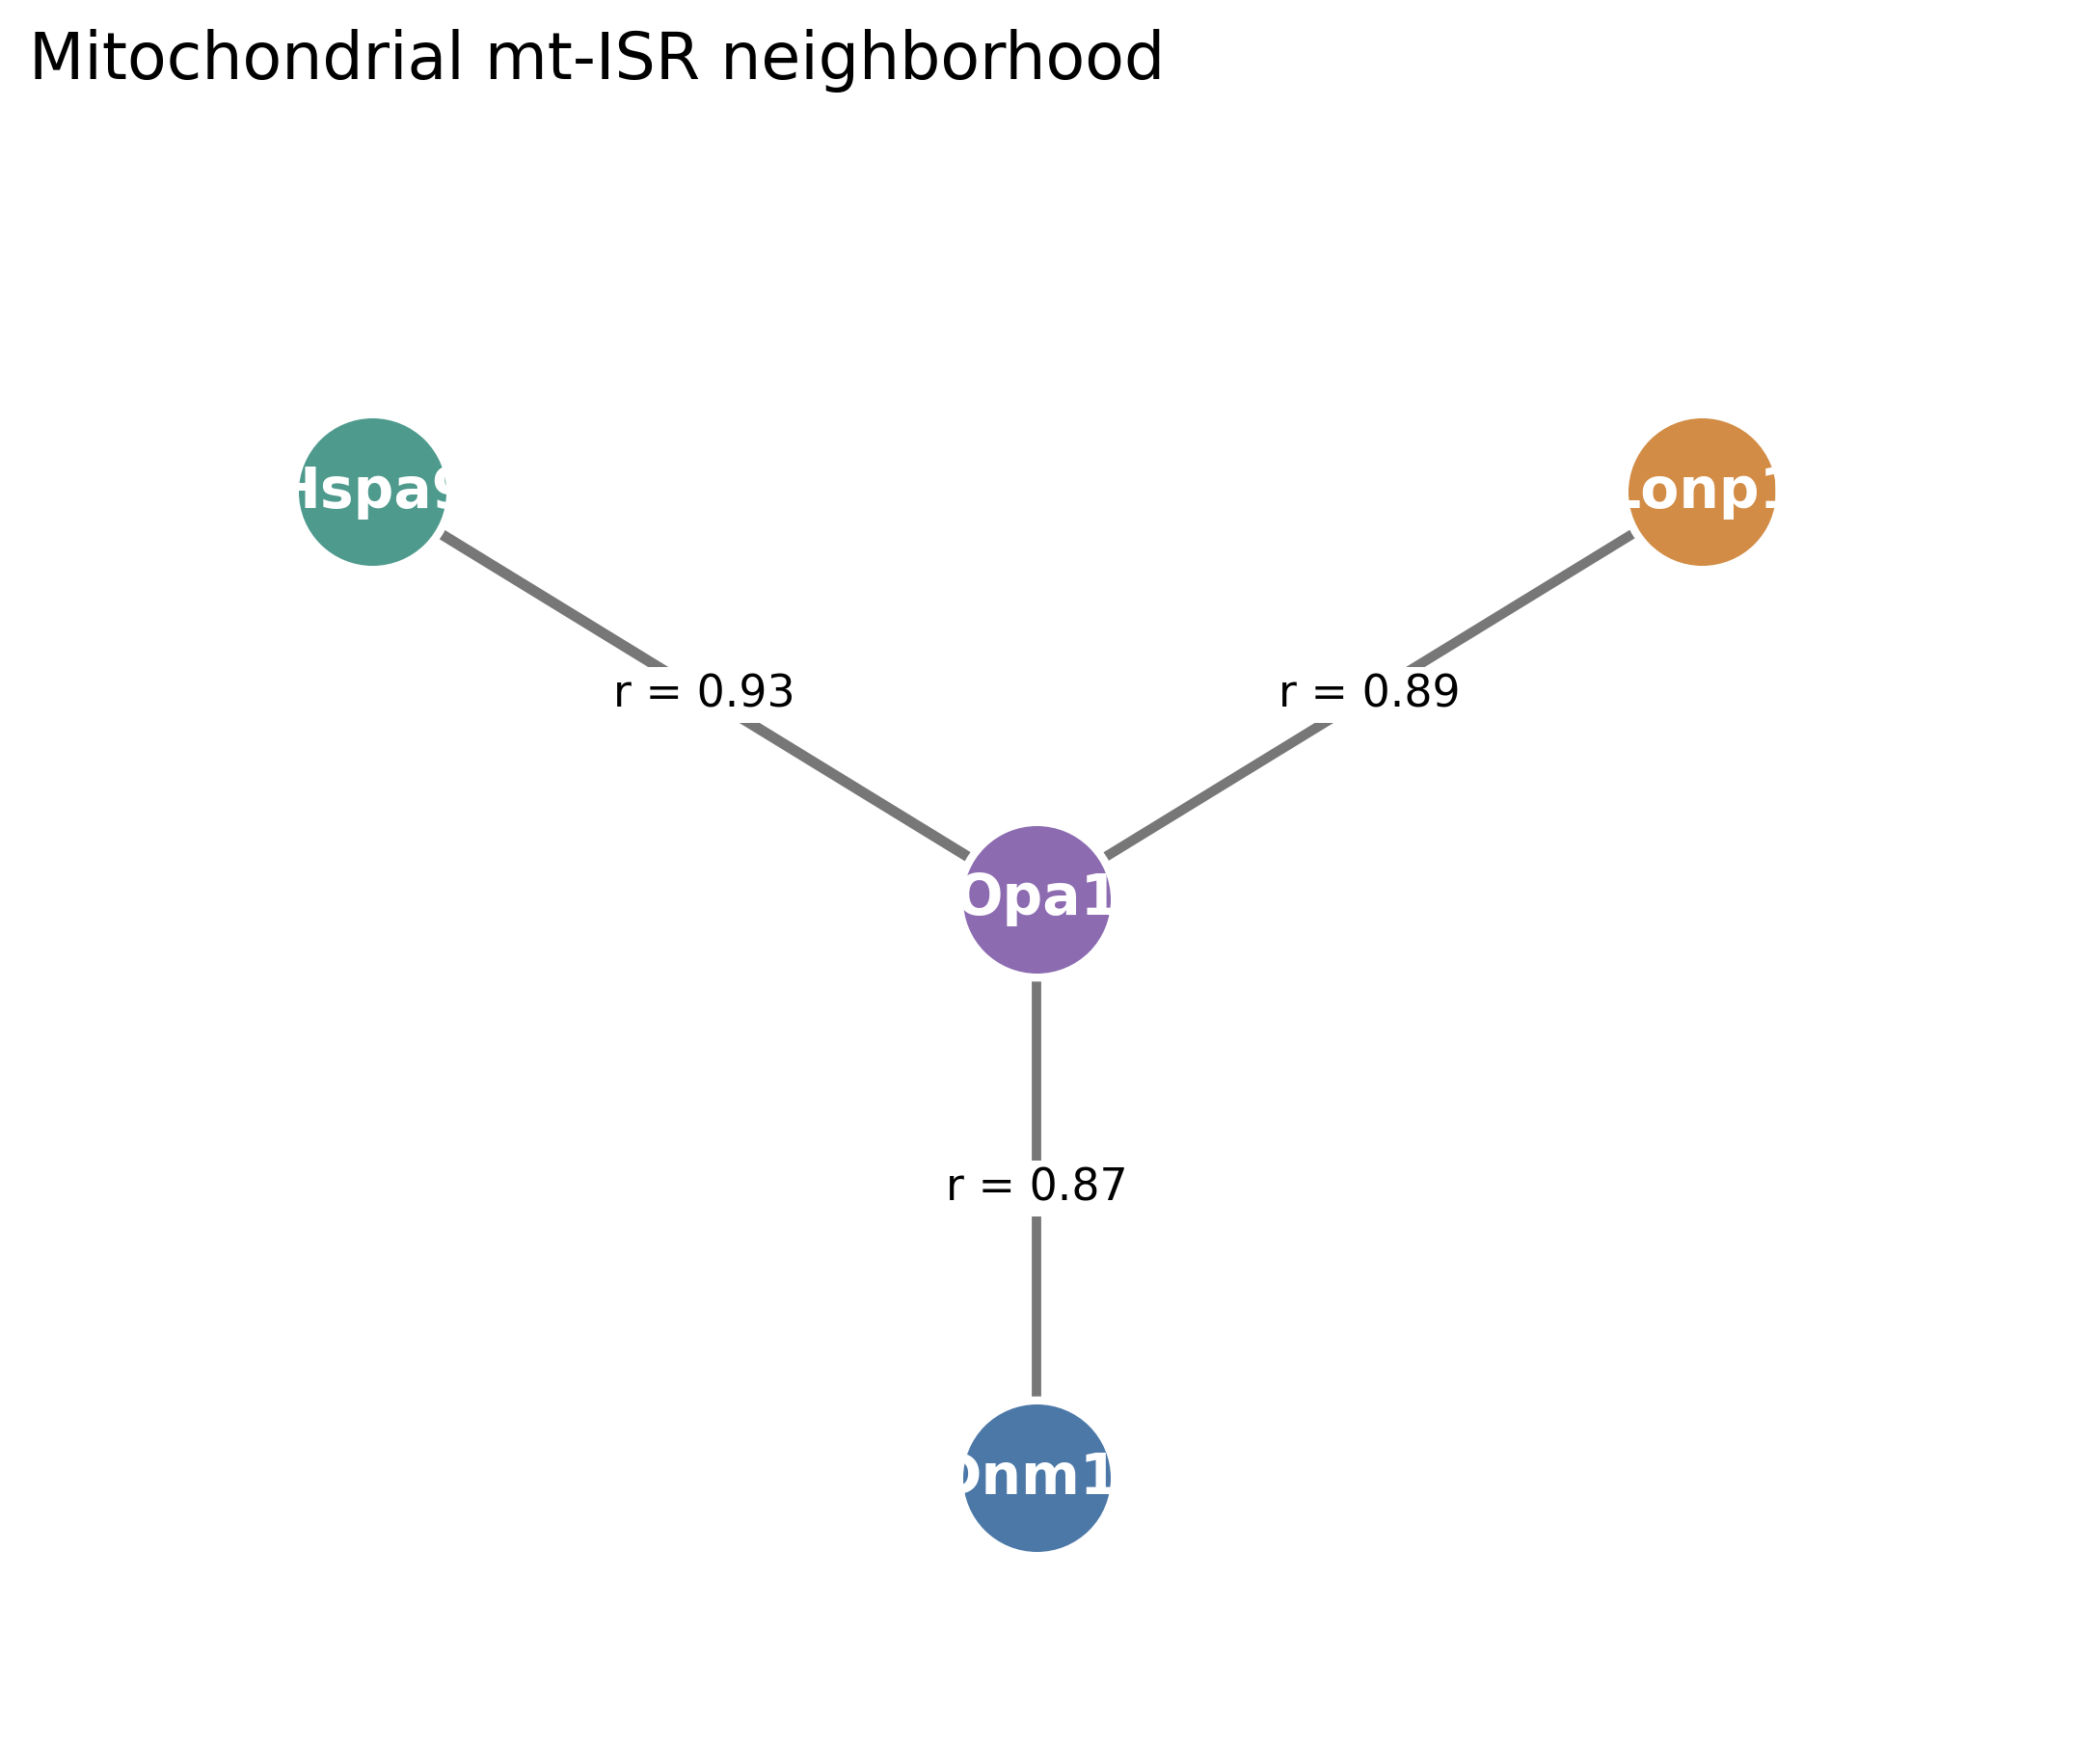

In [22]:
edges = pd.DataFrame([('Opa1', 'Hspa9', 0.93), ('Opa1', 'Lonp1', 0.89), ('Opa1', 'Dnm1l', 0.87)], columns=['reference', 'neighbor', 'reported_r'])
pos = {'Opa1': (0, 0), 'Hspa9': (-1.55, 0.95), 'Lonp1': (1.55, 0.95), 'Dnm1l': (0, -1.35)}
node_colors = {'Opa1': '#8C6BB1', 'Hspa9': '#4E9A8D', 'Lonp1': '#D28C45', 'Dnm1l': '#4C78A8'}
fig, ax = plt.subplots(figsize=(10.5, 6.2))
for row in edges.itertuples():
    x1, y1 = pos[row.reference]
    x2, y2 = pos[row.neighbor]
    ax.plot([x1, x2], [y1, y2], color='#777777', lw=2 + 5 * (row.reported_r - 0.8), zorder=1)
    ax.text((x1 + x2) / 2, (y1 + y2) / 2, f'r = {row.reported_r:.2f}', ha='center', va='center', fontsize=11, bbox=dict(facecolor='white', edgecolor='none', pad=1.5), zorder=3)
for node, (x, y) in pos.items():
    ax.scatter(x, y, s=1500, color=node_colors[node], edgecolor='white', linewidth=2, zorder=4)
    ax.text(x, y, node, ha='center', va='center', fontsize=14, color='white', fontweight='bold', zorder=5)
ax.set_xlim(-2.35, 2.35)
ax.set_ylim(-1.95, 1.65)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Mitochondrial mt-ISR neighborhood', loc='left', fontsize=16, pad=28)
fig.tight_layout()
plt.show()

### 4. Alternative view: module distributions

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


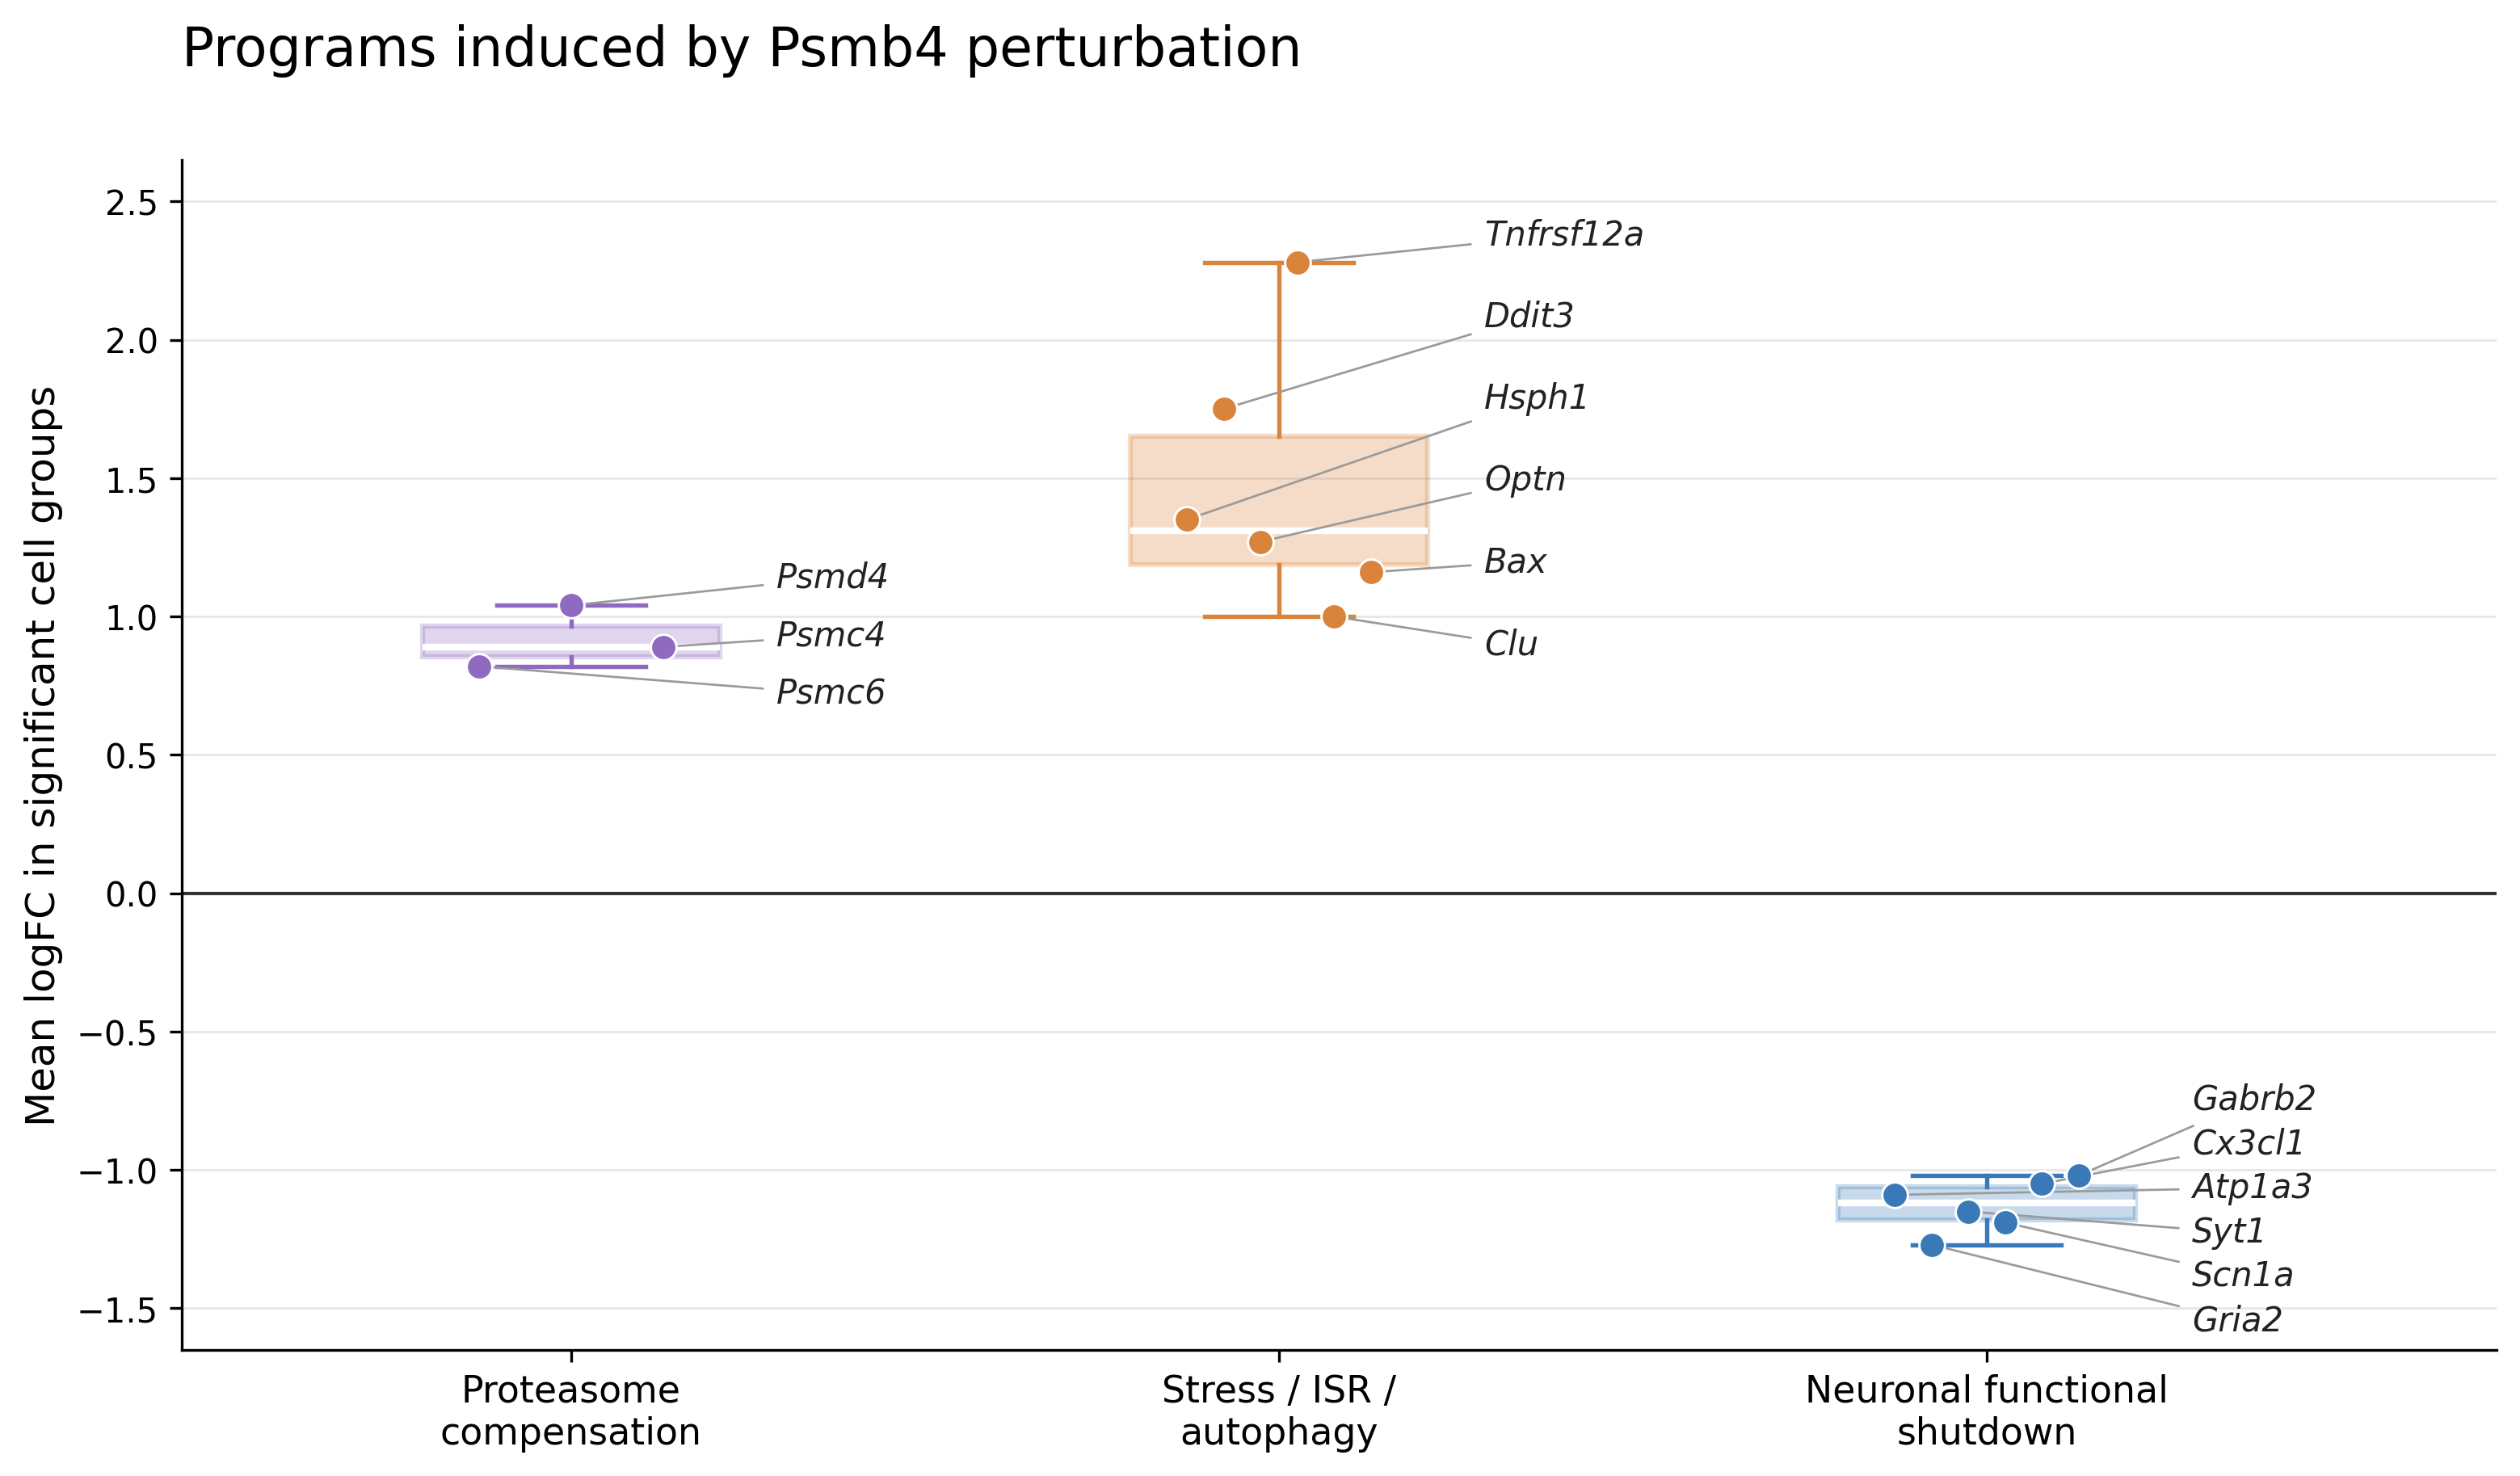

In [23]:
short_labels = {'Proteasome compensation': 'Proteasome\ncompensation', 'Stress / ISR / autophagy': 'Stress / ISR /\nautophagy', 'Neuronal functional shutdown': 'Neuronal functional\nshutdown'}
fig, ax = plt.subplots(figsize=(10.5, 6.2))
rng = np.random.default_rng(18)
for xi, program in enumerate(order):
    d = transition[transition.program.eq(program)].copy()
    vals = d.mean_logFC_in_significant_groups.to_numpy()
    bp = ax.boxplot(vals, positions=[xi], widths=0.42, patch_artist=True, showfliers=False, medianprops=dict(color='white', lw=2), boxprops=dict(facecolor=colors[program], alpha=0.28, color=colors[program], lw=1.5), whiskerprops=dict(color=colors[program], lw=1.3), capprops=dict(color=colors[program], lw=1.3))
    jitter = np.linspace(-0.13, 0.13, len(d)) if len(d) > 1 else np.array([0.0])
    plotted = []
    for row, dx in zip(d.itertuples(), jitter):
        x = xi + dx
        ax.scatter(x, row.mean_logFC_in_significant_groups, s=58, color=colors[program], edgecolor='white', linewidth=0.7, zorder=4)
        plotted.append((row.gene, x, row.mean_logFC_in_significant_groups))
    plotted = sorted(plotted, key=lambda z: z[2])
    center = (min(vals) + max(vals)) / 2
    span = max(max(vals) - min(vals) + 0.2, 0.16 * (len(plotted) - 1))
    label_y = np.linspace(center - span / 2, center + span / 2, len(plotted))
    for (gene, x, y), ly in zip(plotted, label_y):
        ax.annotate(gene, xy=(x, y), xytext=(xi + 0.29, ly), textcoords='data', arrowprops=dict(arrowstyle='-', color='#9A9A9A', lw=0.65), ha='left', va='center', fontsize=10, fontstyle='italic', color='#222222')
ax.axhline(0, color='#333333', lw=1)
ax.set_xticks(range(3), [short_labels[p] for p in order], fontsize=11)
ax.set_ylabel('Mean logFC in significant cell groups', fontsize=12)
ax.set_ylim(-1.65, 2.65)
ax.set_xlim(-0.55, 2.72)
ax.set_title('Programs induced by Psmb4 perturbation', loc='left', fontsize=16, pad=28)
ax.grid(axis='y', color='#E5E5E5', lw=0.6)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
fig.tight_layout()
plt.show()

## Figure 1F — SWI/SNF compensatory gain arm

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib as mpl
import matplotlib.pyplot as plt
OUT = ROOT / 'src/manuscript_figures/fig1/f'
DEG = DEG_PATH
GROUP = '151 TH Prkcd Grin2c Glut'
ORDER = ['Smarcb1', 'Smarcc2']
COLORS = {'Smarcb1': '#7B68B5', 'Smarcc2': '#4FA39B'}
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42})

In [25]:
modules = {'Smarcb1': {'Neuronal remodeling / re-specification': ['Myt1', 'Stmn1', 'Clstn1', 'Clstn2', 'Plxna2', 'Fez2', 'Syt4', 'Nexn'], 'Stress / DNA-damage / quality control': ['Atm', 'Prkn', 'Gss', 'Hsf2', 'Abcc1', 'Ubc'], 'Alternative neuromodulatory state': ['Grm5', 'Pth2r', 'Tafa1', 'Kcnj9']}, 'Smarcc2': {'Compensatory neuronal remodeling': ['Pth2r', 'Tafa1', 'Grin3a', 'Syt4', 'Rims4', 'Grm5']}}
rows = []
for perturbation, mm in modules.items():
    for module, genes in mm.items():
        rows += [(perturbation, g, module) for g in genes]
membership = pd.DataFrame(rows, columns=['perturbation', 'gene', 'report_module']).drop_duplicates(['perturbation', 'gene'])
tab = pq.read_table(DEG, columns=['names', 'gene_target', 'logfoldchanges', 'pvals_adj'], filters=[('group_name', '=', GROUP), ('gene_target', 'in', ORDER)])
raw = tab.to_pandas().rename(columns={'names': 'gene', 'gene_target': 'perturbation', 'logfoldchanges': 'logFC', 'pvals_adj': 'FDR'})
df = membership.merge(raw, on=['perturbation', 'gene'], how='left', validate='one_to_one')
assert df.logFC.notna().all()
df.groupby(['perturbation', 'report_module']).agg(n=('gene', 'size'), mean_logFC=('logFC', 'mean'))

n  mean_logFC
perturbation report_module                                        
Smarcb1      Alternative neuromodulatory state       4    0.835429
             Neuronal remodeling / re-specification  8    0.439520
             Stress / DNA-damage / quality control   6    0.449655
Smarcc2      Compensatory neuronal remodeling        6    0.905617

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


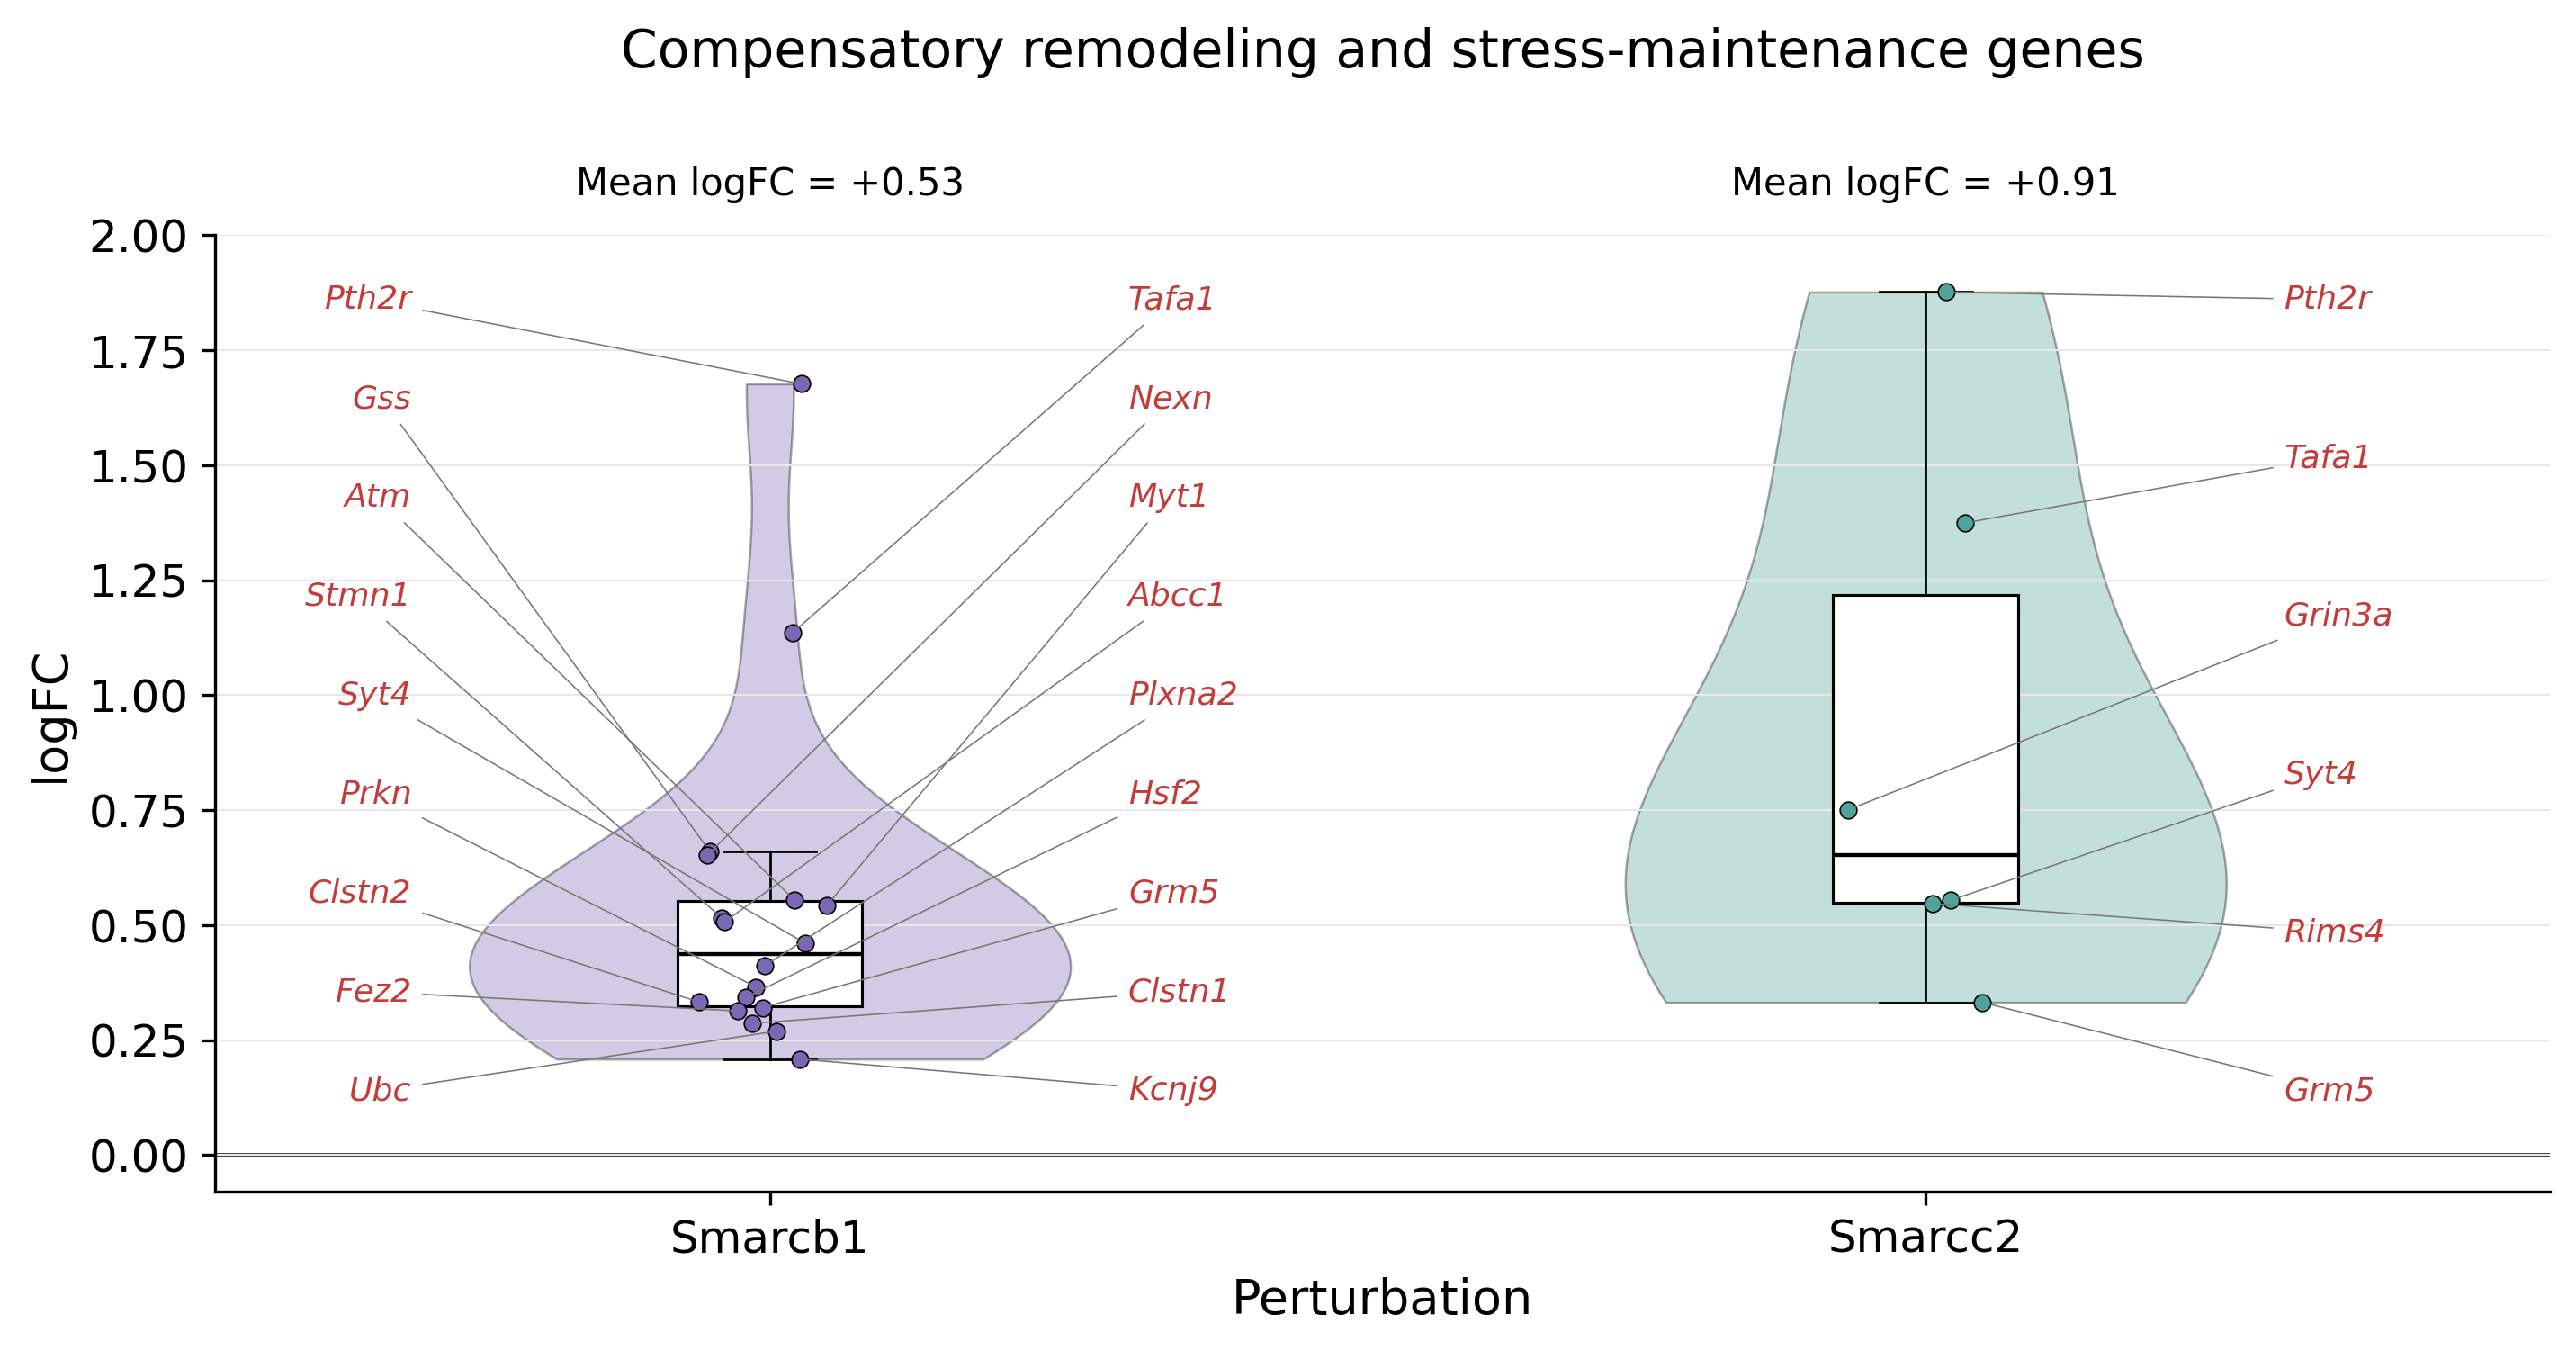

In [26]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
rng = np.random.default_rng(23)
for x, perturbation in enumerate(ORDER):
    d = df[df.perturbation.eq(perturbation)].sort_values('logFC', ascending=False).copy()
    vals = d.logFC.to_numpy()
    vp = ax.violinplot(vals, positions=[x], widths=0.52, showmeans=False, showmedians=False, showextrema=False)
    for body in vp['bodies']:
        body.set_facecolor(COLORS[perturbation])
        body.set_edgecolor('black')
        body.set_linewidth(0.6)
        body.set_alpha(0.34)
    ax.boxplot(vals, positions=[x], widths=0.16, patch_artist=True, showfliers=False, boxprops=dict(facecolor='white', edgecolor='black', linewidth=0.75), medianprops=dict(color='black', linewidth=1.05), whiskerprops=dict(color='black', linewidth=0.65), capprops=dict(color='black', linewidth=0.65))
    jitter = rng.uniform(-0.07, 0.07, len(vals))
    px = x + jitter
    ax.scatter(px, vals, s=20, color=COLORS[perturbation], edgecolor='black', linewidth=0.4, zorder=5)
    if perturbation == 'Smarcb1':
        groups = [(d.iloc[::2], x - 0.31, 'right'), (d.iloc[1::2], x + 0.31, 'left')]
    else:
        groups = [(d, x + 0.31, 'left')]
    for gd, label_x, ha in groups:
        label_y = np.linspace(1.86, 0.14, len(gd))
        for (_, row), ly in zip(gd.iterrows(), label_y):
            idx = d.index.get_loc(row.name)
            ax.annotate(row.gene, xy=(px[idx], row.logFC), xytext=(label_x, ly), ha=ha, va='center', fontsize=8.7, fontstyle='italic', color='#C43C39', arrowprops=dict(arrowstyle='-', color='#777777', lw=0.38, shrinkA=1, shrinkB=2), annotation_clip=False, zorder=6)
    ax.text(x, 2.07, f'Mean logFC = {vals.mean():+.2f}', ha='center', va='bottom', fontsize=10, clip_on=False)
ax.axhline(0, color='#222222', lw=0.9, zorder=1)
ax.set_xticks(range(2), ORDER)
ax.set_xlim(-0.48, 1.54)
ax.set_ylim(-0.08, 2.0)
ax.set_ylabel('logFC', fontsize=13)
ax.set_xlabel('Perturbation', fontsize=13)
ax.tick_params(axis='both', labelsize=12)
ax.set_title('Compensatory remodeling and stress-maintenance genes', loc='center', fontsize=14, y=1.16, pad=4)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', color='#E8E8E8', lw=0.5, zorder=0)
fig.tight_layout(pad=0.55)
for ext in ['pdf']:
    kw = {'bbox_inches': 'tight', 'pad_inches': 0.03}
    if ext == 'png':
        kw['dpi'] = 300
plt.show()

## Figure 1F — Grin2a/Grin2b neighborhoods

In [27]:
from pathlib import Path
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
OUT = ROOT / 'src/manuscript_figures/fig1/f'
mpl.rcParams.update({'font.family': 'Arial', 'font.sans-serif': ['Arial'], 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'ps.fonttype': 42})
a = pd.DataFrame([('Gabrg2', 0.18), ('Kcnb1', 0.169), ('Gphn', 0.12), ('Kcnn2', 0.097), ('Nlgn2', 0.095), ('Grin2b', -0.114), ('Camk2a', -0.136)], columns=['perturbation', 'r'])
b = pd.DataFrame([('Iqsec2', 0.82), ('Baiap2', 0.78), ('Shank2', 0.76), ('Camk2a', 0.72), ('Syngap1', 0.72), ('Homer2', 0.68), ('Grin2a', -0.63), ('Eef2', -0.58), ('Celf2', -0.51), ('Ppp2r1a', -0.48), ('Mef2c', -0.38)], columns=['perturbation', 'r'])

/tmp/ipykernel_3247521/304278192.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 1))
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


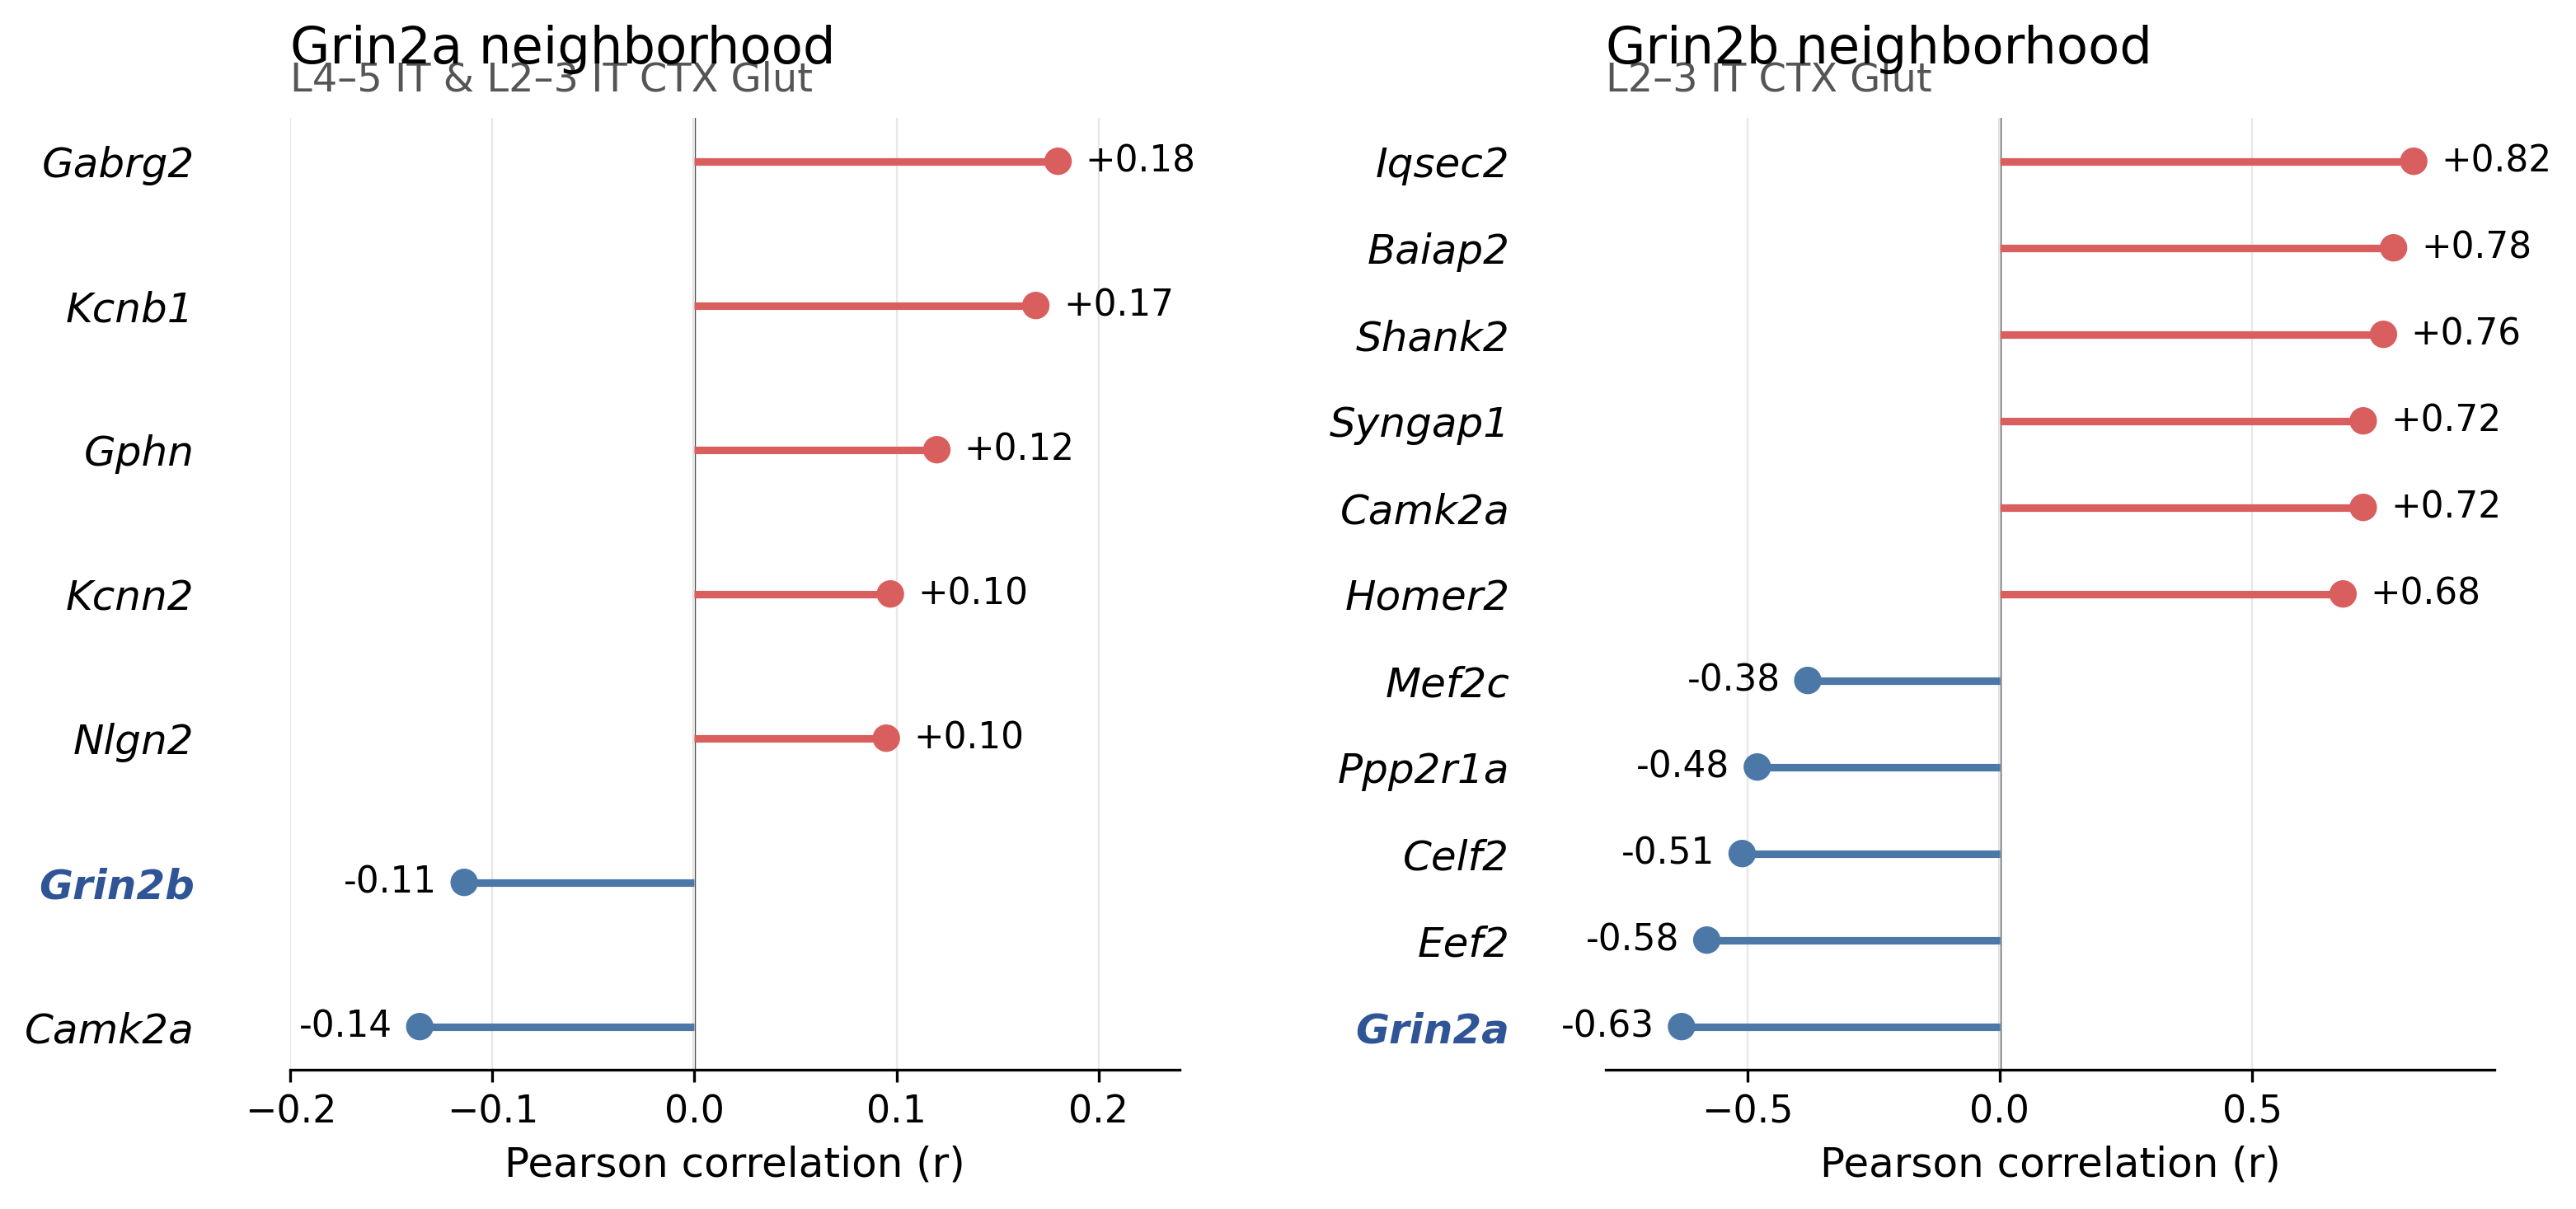

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.0), gridspec_kw={'wspace': 0.48})
panels = [(axes[0], a, 'Grin2a neighborhood', 'L4–5 IT & L2–3 IT CTX Glut'), (axes[1], b, 'Grin2b neighborhood', 'L2–3 IT CTX Glut')]
for ax, d, title, subtitle in panels:
    d = d.sort_values('r').reset_index(drop=True)
    y = range(len(d))
    colors = ['#D95F5F' if v > 0 else '#4C78A8' for v in d.r]
    ax.hlines(y, 0, d.r, color=colors, lw=2.2, zorder=2)
    ax.scatter(d.r, y, s=64, color=colors, edgecolor='none', zorder=3)
    ax.axvline(0, color='#333333', lw=0.8, zorder=1)
    ax.set_yticks(list(y), d.perturbation, fontstyle='italic', fontsize=12)
    for yi, row in d.iterrows():
        ax.annotate(f'{row.r:+.2f}', xy=(row.r, yi), xytext=(8 if row.r >= 0 else -8, 0), textcoords='offset points', ha='left' if row.r >= 0 else 'right', va='center', fontsize=10.5)
    for tick in ax.get_yticklabels():
        if tick.get_text() in {'Grin2a', 'Grin2b'}:
            tick.set_fontweight('bold')
            tick.set_color('#2F5597')
    ax.set_title(title, loc='left', fontsize=15, pad=16, fontweight='normal')
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha='left', va='bottom', fontsize=11.5, color='#555555')
    ax.set_xlabel('Pearson correlation (r)', fontsize=12)
    ax.tick_params(axis='x', labelsize=11)
    ax.grid(axis='x', color='#E7E7E7', lw=0.55, zorder=0)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0, pad=28)
axes[0].set_xlim(-0.2, 0.24)
axes[1].set_xlim(-0.78, 0.98)
fig.tight_layout(rect=(0, 0, 1, 1))
for ext in ['pdf']:
    kw = {'bbox_inches': 'tight', 'pad_inches': 0.04}
    if ext == 'png':
        kw['dpi'] = 300
plt.show()